# Climate Change Trend Analysis and Forecasting

## Table of Contents

1. [Week 1 - Data Collection and Exploratory Data Analysis(EDA)]

2. [Week 2 - Feature Engineering]

3. [Week 3 - Baseline Machine Learning Models]

4. [Week 4 - ETS(A,Ad,N)Time Series Forecasting]

5. [Week 5 - Scenario Analysis]

# Week 1 – Data Collection and Exploratory Data Analysis (EDA)

- China
- United States
- India
- Russia
- Japan
- Germany
- Brazil
- United Kingdom
- South Africa
- Australia

Objectives:

1. Analyze historical emissions trends
2. Create time-series features
3. Train forecasting models
4. Predict future emissions
5. Compare forecasting approaches

In [1]:
import os

import urllib.request

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import matplotlib.ticker as mticker

Checking whether dataset exists locally.
If not available, download from OWID GitHub.

### Downloading the Dataset

The following code checks whether the OWID dataset already exists locally. If it is not available, it is downloaded from the official GitHub repository.

In [2]:
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"

local_path = "data/owid-co2-data.csv"

if not os.path.exists(local_path):
    
    urllib.request.urlretrieve(url, local_path)

    print("Downloaded")

else:
    
    print("Already Exists")

Already Exists


### Loading the Dataset

The downloaded dataset is loaded into a pandas DataFrame. The dataset dimensions, column names, and sample records are displayed to understand its structure.

In [3]:
df = pd.read_csv(local_path)

print(df.shape)

print(df.columns.tolist())

(50411, 79)
['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'methane_per_capita', 'nitrous_oxide', 'nitrous_oxide_p

In [4]:
print(df.head(10))

df.tail(5)

       country  year iso_code  population  gdp  cement_co2  \
0  Afghanistan  1750      AFG   2802560.0  NaN         0.0   
1  Afghanistan  1751      AFG         NaN  NaN         0.0   
2  Afghanistan  1752      AFG         NaN  NaN         0.0   
3  Afghanistan  1753      AFG         NaN  NaN         0.0   
4  Afghanistan  1754      AFG         NaN  NaN         0.0   
5  Afghanistan  1755      AFG         NaN  NaN         0.0   
6  Afghanistan  1756      AFG         NaN  NaN         0.0   
7  Afghanistan  1757      AFG         NaN  NaN         0.0   
8  Afghanistan  1758      AFG         NaN  NaN         0.0   
9  Afghanistan  1759      AFG         NaN  NaN         0.0   

   cement_co2_per_capita  co2  co2_growth_abs  co2_growth_prct  ...  \
0                    0.0  NaN             NaN              NaN  ...   
1                    NaN  NaN             NaN              NaN  ...   
2                    NaN  NaN             NaN              NaN  ...   
3                    NaN  NaN    

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
50406,Zimbabwe,2020,ZWE,15526887.0,2.317871e+10,0.496,0.032,8.491,-1.776,-17.298,...,NaN,0.106,0.001,0.001,0.002,0.0,24.146,14.463,1.991,23.450
50407,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,0.542,0.034,10.223,1.732,20.398,...,NaN,0.105,0.001,0.001,0.002,0.0,27.907,16.408,2.137,20.899
50408,Zimbabwe,2022,ZWE,16069061.0,2.590159e+10,0.387,0.024,12.232,2.009,19.653,...,NaN,0.104,0.001,0.001,0.002,0.0,29.917,18.830,1.380,11.283
50409,Zimbabwe,2023,ZWE,16340829.0,NaN,0.387,0.024,13.443,1.211,9.904,...,NaN,0.103,0.001,0.001,0.002,0.0,31.029,20.318,1.876,13.957
50410,Zimbabwe,2024,ZWE,16634366.0,NaN,0.387,0.023,13.701,0.258,1.918,...,NaN,0.102,0.001,0.001,0.002,0.0,31.066,20.773,NaN,NaN


### Checking Missing Values

This section calculates the percentage of missing values for every column to evaluate data completeness.

In [5]:
missing = (df.isnull().sum()/len(df))*100
missing.to_frame("NULL%")

,NULL%
country,0.000000
year,0.000000
iso_code,15.732677
population,18.337268
gdp,69.746682
...,...
temperature_change_from_n2o,24.064192
total_ghg,24.322073
total_ghg_excluding_lucf,24.990577
trade_co2,90.652834


### Key Variables

- **country** – Name of the country.
- **year** – Observation year.
- **co2** – Annual carbon dioxide emissions.
- **co2_per_capita** – Carbon dioxide emissions per person.
- **methane** – Methane emissions.
- **nitrous_oxide** – Nitrous oxide emissions.
- **total_ghg** – Total greenhouse gas emissions.

In [6]:
required_cols = [
    'co2',
    'co2_per_capita',
    'methane',
    'nitrous_oxide',
    'total_ghg',
]

### Data Coverage by Country

The completeness of the selected greenhouse gas variables is calculated for every country to identify which countries contain the most complete historical records.

In [7]:
country_coverage = (df.groupby("country")[required_cols].apply(lambda data:data.notna().mean().mean()*100).sort_values(ascending=False))
country_coverage.head(10)

country
Mexico         98.628571
Cuba           98.628571
Uruguay        98.628571
Brazil         98.628571
Colombia       98.628571
Argentina      98.628571
Peru           98.628571
Romania        98.171429
Switzerland    98.171429
Chile          98.011050
dtype: float64

### Data Coverage by Year

The completeness of greenhouse gas variables is also examined across years to identify periods with the highest data availability.

In [8]:
year_coverage = (
    df.groupby("year")[required_cols]
      .apply(lambda x: x.notna().mean().mean()*100)
      .sort_values(ascending=False)
)
year_coverage.head(10)

year
2024    89.291339
2009    89.291339
1994    89.291339
1995    89.291339
1996    89.291339
1997    89.291339
1998    89.291339
1999    89.291339
2000    89.291339
2001    89.291339
dtype: float64

### Filtering the Dataset

The dataset is filtered to include observations from 1990 onwards for the ten selected project countries. Aggregated regions such as World, Asia and Europe are excluded because the project focuses only on sovereign nations.

In [9]:
df[["country","iso_code"]].drop_duplicates()
filtered_dataset = (df.dropna(subset=["iso_code"]))
countries = [
    "China",
    "United States",
    "India",
    "Russia",
    "Japan",
    "Germany",
    "Brazil",
    "United Kingdom",
    "South Africa",
    "Australia"
]

filtered_dataset = df[(df["year"] >= 1990) & (df["country"].isin(countries))].copy() 
filtered_dataset

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
3644,Australia,1990,AUS,17126304.0,4.641366e+11,3.463,0.202,278.061,21.223,8.263,...,0.666,1.693,0.007,0.008,0.017,0.002,538.479,336.927,-33.380,-12.005
3645,Australia,1991,AUS,17353191.0,4.613021e+11,3.183,0.183,279.437,1.376,0.495,...,0.643,1.687,0.007,0.008,0.017,0.002,522.525,339.829,-34.011,-12.171
3646,Australia,1992,AUS,17549286.0,4.786337e+11,2.923,0.167,284.433,4.996,1.788,...,0.699,1.680,0.007,0.008,0.017,0.002,568.962,346.607,-36.367,-12.786
3647,Australia,1993,AUS,17722905.0,5.015248e+11,3.005,0.170,288.780,4.347,1.528,...,0.810,1.677,0.007,0.008,0.017,0.002,580.666,350.855,-40.004,-13.853
3648,Australia,1994,AUS,17897433.0,5.279932e+11,3.484,0.195,293.613,4.833,1.674,...,0.924,1.671,0.007,0.008,0.018,0.002,554.084,353.411,-35.667,-12.148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48003,United States,2020,USA,339436156.0,1.802736e+13,40.688,0.120,4689.954,-545.958,-10.427,...,30.237,18.090,0.037,0.238,0.286,0.011,5758.456,5309.856,413.131,8.809
48004,United States,2021,USA,340161438.0,1.909938e+13,41.312,0.121,5020.111,330.157,7.040,...,31.844,17.980,0.037,0.240,0.288,0.011,6131.129,5675.305,469.552,9.353
48005,United States,2022,USA,341534041.0,1.949317e+13,41.884,0.123,5055.403,35.292,0.703,...,30.882,17.870,0.038,0.242,0.291,0.011,6201.504,5728.265,510.586,10.100
48006,United States,2023,USA,343477330.0,NaN,40.636,0.118,4918.407,-136.996,-2.710,...,31.847,17.759,0.038,0.245,0.294,0.011,6078.455,5606.243,513.252,10.435


In [10]:
df = df.sort_values(
    ['country','year']
)

In [11]:
df['country'].value_counts()

country
Afghanistan                  275
Africa                       275
Andorra                      275
Antarctica                   275
Asia                         275
                            ... 
Saint Pierre and Miquelon    174
Sint Maarten (Dutch part)    174
Wallis and Futuna            174
Ryukyu Islands (GCP)          52
Kuwaiti Oil Fires (GCP)       32
Name: count, Length: 254, dtype: int64

Plotting total global CO₂ emissions trend.

### Global CO₂ Emissions Trend

This visualization shows the overall trend in global carbon dioxide emissions from 1990 onwards.

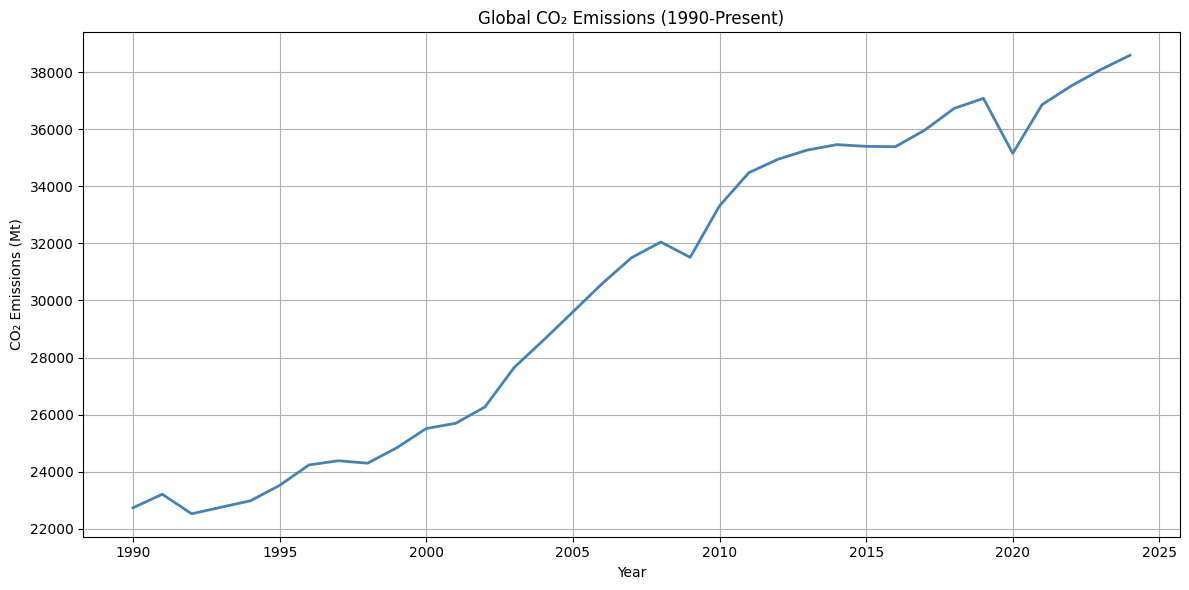

In [12]:
global_co2 = df[(df["country"]=="World")&(df["year"]>=1990)]
plt.figure(figsize=(12,6))

plt.plot(
    global_co2['year'],
    global_co2['co2'],
    color='steelblue',
    linewidth=2
)
plt.title("Global CO₂ Emissions (1990-Present)")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (Mt)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

Global CO₂ emissions increased steadily from 1990 onwards, with especially rapid growth during the 2000s. A temporary decline is visible around 2020 due to the COVID-19 pandemic before emissions recovered in later years.

### CO₂ Emission Trends of Major Emitters

The following chart compares historical CO₂ emissions for the five largest emitting countries included in this project.

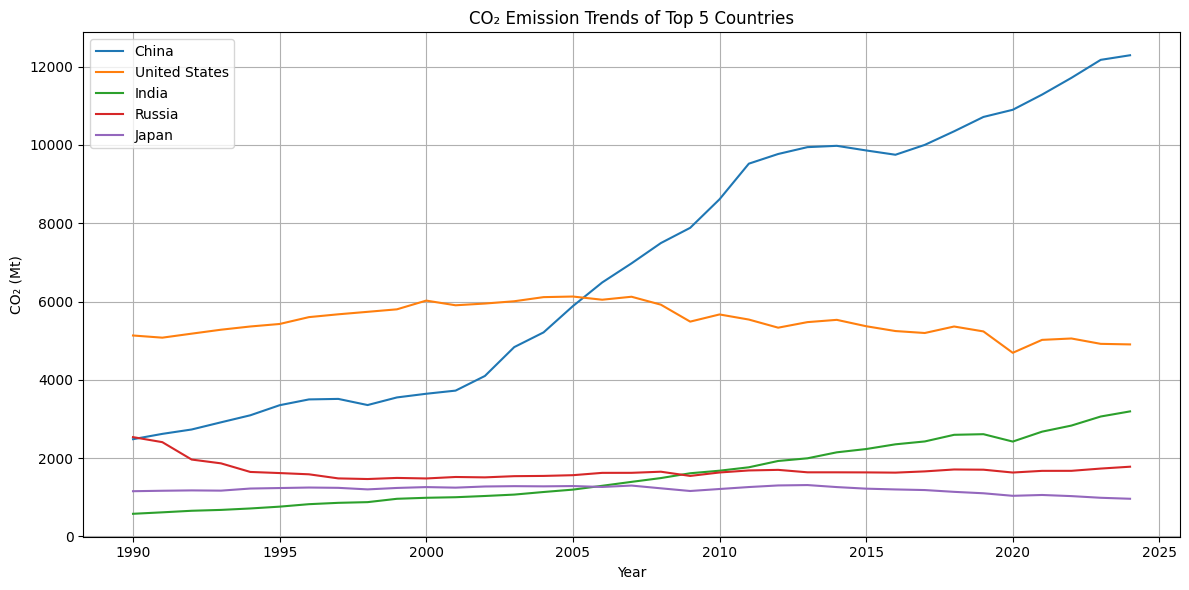

In [13]:
countries_emitters = [
'China',
'United States',
'India',
'Russia',
'Japan',
]
plt.figure(figsize=(12,6))
for country in countries_emitters:
    temp = filtered_dataset[filtered_dataset['country']==country]

    plt.plot(
        temp['year'],
        temp['co2'],
        label=country
    )

plt.title("CO₂ Emission Trends of Top 5 Countries")
plt.xlabel("Year")
plt.ylabel("CO₂ (Mt)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

China shows the strongest increase in emissions after 2000. India also exhibits continuous growth, while the United States shows a gradual decline in recent years. Russia and Japan remain comparatively stable.

In [14]:
global_co2 = global_co2.copy()
global_co2['decade'] = (
    global_co2['year']//10
)*10

### Greenhouse Gas Composition by Decade

This chart compares the contribution of different greenhouse gases across decades.

In [15]:
gas = global_co2.groupby('decade')[
['co2','methane','nitrous_oxide']
].sum()

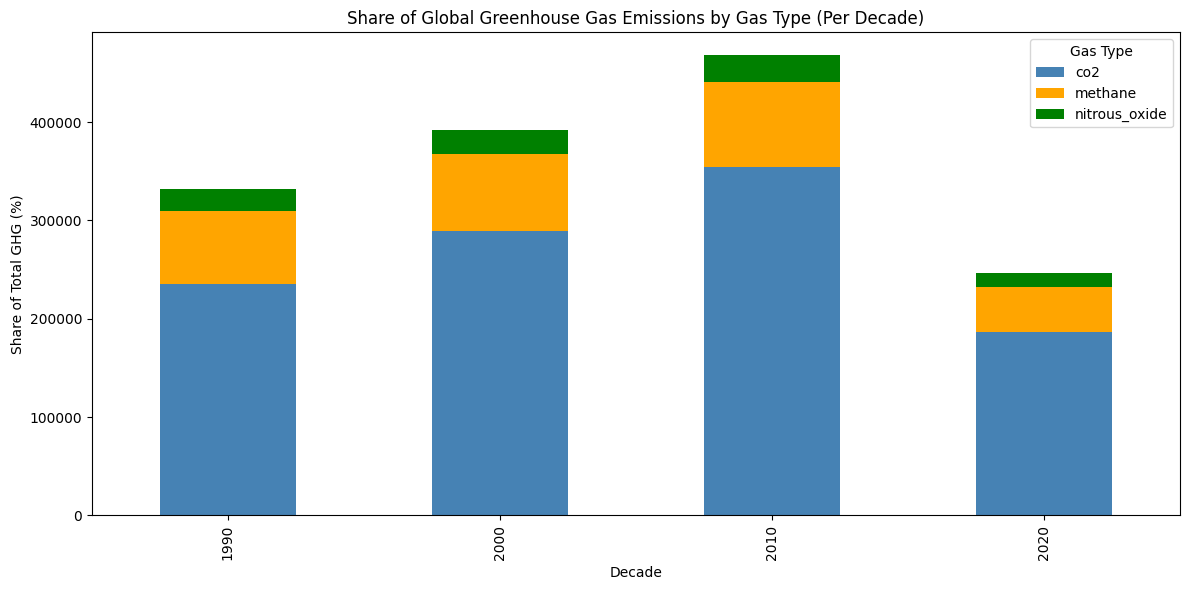

In [16]:
gas.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=['steelblue', 'orange', 'green']
)

plt.title("Share of Global Greenhouse Gas Emissions by Gas Type (Per Decade)")

plt.xlabel("Decade")

plt.ylabel("Share of Total GHG (%)")

plt.legend(title="Gas Type")

plt.tight_layout()

plt.show()

### Observation

Carbon dioxide contributes the largest share of greenhouse gas emissions across every decade. Methane represents the second largest contributor, while nitrous oxide remains comparatively smaller.

### Saving the Filtered Dataset

The cleaned dataset is saved for use in Week 2 feature engineering.

In [17]:
filtered_dataset.to_csv("data/filtered_dataset.csv",index=False)

## Week 1 Summary

In this notebook, the greenhouse gas emissions dataset was collected and explored. Missing values and data coverage were examined, and historical emission trends were visualized for the selected countries. The cleaned dataset will be used in the next stage for feature engineering.

# Week 2 – Feature Engineering

## Objective

The objective of this notebook is to create additional features that improve the predictive capability of machine learning models. Time-series features such as lag values, rolling averages, year-over-year changes, and greenhouse gas intensity are generated.

### Importing Libraries

The required libraries are imported and the filtered dataset prepared in Week 1 is loaded.

### Loading the Filtered Dataset

The cleaned dataset generated during Week 1 is loaded for feature engineering.

In [18]:
import pandas as pd 
import numpy as np
filtered_dataset = pd.read_csv("data/filtered_dataset.csv")
filtered_dataset

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Australia,1990,AUS,17126304.0,4.641366e+11,3.463,0.202,278.061,21.223,8.263,...,0.666,1.693,0.007,0.008,0.017,0.002,538.479,336.927,-33.380,-12.005
1,Australia,1991,AUS,17353191.0,4.613021e+11,3.183,0.183,279.437,1.376,0.495,...,0.643,1.687,0.007,0.008,0.017,0.002,522.525,339.829,-34.011,-12.171
2,Australia,1992,AUS,17549286.0,4.786337e+11,2.923,0.167,284.433,4.996,1.788,...,0.699,1.680,0.007,0.008,0.017,0.002,568.962,346.607,-36.367,-12.786
3,Australia,1993,AUS,17722905.0,5.015248e+11,3.005,0.170,288.780,4.347,1.528,...,0.810,1.677,0.007,0.008,0.017,0.002,580.666,350.855,-40.004,-13.853
4,Australia,1994,AUS,17897433.0,5.279932e+11,3.484,0.195,293.613,4.833,1.674,...,0.924,1.671,0.007,0.008,0.018,0.002,554.084,353.411,-35.667,-12.148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,United States,2020,USA,339436156.0,1.802736e+13,40.688,0.120,4689.954,-545.958,-10.427,...,30.237,18.090,0.037,0.238,0.286,0.011,5758.456,5309.856,413.131,8.809
346,United States,2021,USA,340161438.0,1.909938e+13,41.312,0.121,5020.111,330.157,7.040,...,31.844,17.980,0.037,0.240,0.288,0.011,6131.129,5675.305,469.552,9.353
347,United States,2022,USA,341534041.0,1.949317e+13,41.884,0.123,5055.403,35.292,0.703,...,30.882,17.870,0.038,0.242,0.291,0.011,6201.504,5728.265,510.586,10.100
348,United States,2023,USA,343477330.0,NaN,40.636,0.118,4918.407,-136.996,-2.710,...,31.847,17.759,0.038,0.245,0.294,0.011,6078.455,5606.243,513.252,10.435


### Creating the Decade Feature

A decade column is created to support decade-wise analysis and visualization.

In [19]:
filtered_dataset["decade"] = ( filtered_dataset["year"] // 10)*10
filtered_dataset[["year","decade"]].head(5)

,year,decade
0,1990,1990
1,1991,1990
2,1992,1990
3,1993,1990
4,1994,1990


### Creating a Time Index

The years_since_1990 feature provides a simple numerical representation of time for regression models.

In [20]:
filtered_dataset['years_since_1990'] = filtered_dataset['year'] - 1990
filtered_dataset[["year","years_since_1990"]].head(5)

,year,years_since_1990
0,1990,0
1,1991,1
2,1992,2
3,1993,3
4,1994,4


### Creating a Five-Year Rolling Mean

A rolling average smooths short-term fluctuations and highlights long-term emission trends.

In [21]:
filtered_dataset['co2_5yr_rolling_mean'] = (

filtered_dataset.groupby('country')['co2']

.transform(lambda x:x.rolling(window=5,min_periods=1).mean())
)

In [22]:
filtered_dataset[["country","year","co2","population","co2_per_capita","co2_5yr_rolling_mean"]].head()

,country,year,co2,population,co2_per_capita,co2_5yr_rolling_mean
0,Australia,1990,278.061,17126304.0,16.236,278.061000
1,Australia,1991,279.437,17353191.0,16.103,278.749000
2,Australia,1992,284.433,17549286.0,16.208,280.643667
3,Australia,1993,288.780,17722905.0,16.294,282.677750
4,Australia,1994,293.613,17897433.0,16.405,284.864800


### Creating Lag Features

Lag features represent emissions from previous years and allow machine learning models to capture temporal relationships between consecutive observations.

In [23]:
filtered_dataset['co2_lag1'] = filtered_dataset.groupby('country')['co2'].shift(1)
filtered_dataset['co2_lag2'] = filtered_dataset.groupby('country')['co2'].shift(2)
filtered_dataset['co2_lag3'] = filtered_dataset.groupby('country')['co2'].shift(3)

In [24]:
filtered_dataset[["country","year","co2","co2_lag1","co2_lag1","co2_lag3"]].head(15)

,country,year,co2,co2_lag1,co2_lag1,co2_lag3
0,Australia,1990,278.061,NaN,NaN,NaN
1,Australia,1991,279.437,278.061,278.061,NaN
2,Australia,1992,284.433,279.437,279.437,NaN
3,Australia,1993,288.780,284.433,284.433,278.061
4,Australia,1994,293.613,288.780,288.780,279.437
5,Australia,1995,304.962,293.613,293.613,284.433
6,Australia,1996,311.851,304.962,304.962,288.780
7,Australia,1997,320.243,311.851,311.851,293.613
8,Australia,1998,334.038,320.243,320.243,304.962
9,Australia,1999,343.876,334.038,334.038,311.851


### Verifying CO₂ Per Capita

The provided CO₂ per capita values are verified by manually calculating them using total CO₂ emissions and population.

In [25]:
filtered_dataset["calculated_co2_per_capita"] = (filtered_dataset["co2"]*1000000 /filtered_dataset["population"])

In [26]:
verification = filtered_dataset[
    filtered_dataset["country"].isin(
        ["India","China","United States"]
    )
][[
    "country",
    "year",
    "co2_per_capita",
    "calculated_co2_per_capita"
]].head(9)

verification

,country,year,co2_per_capita,calculated_co2_per_capita
70,China,1990,2.153,2.152888
71,China,1991,2.237,2.237076
72,China,1992,2.306,2.305715
73,China,1993,2.434,2.434029
74,China,1994,2.559,2.559043
75,China,1995,2.747,2.746581
76,China,1996,2.843,2.842785
77,China,1997,2.830,2.829939
78,China,1998,2.682,2.682451


### Creating Greenhouse Gas Intensity

Greenhouse gas intensity measures total greenhouse gas emissions relative to GDP and provides an indication of emissions efficiency.

In [27]:
filtered_dataset["ghg_intensity"] =(filtered_dataset["total_ghg"] /filtered_dataset["gdp"])

filtered_dataset[[ "country","year","total_ghg","gdp","ghg_intensity"]].head(10)

,country,year,total_ghg,gdp,ghg_intensity
0,Australia,1990,538.479,4.641366e+11,1.160174e-09
1,Australia,1991,522.525,4.613021e+11,1.132718e-09
2,Australia,1992,568.962,4.786337e+11,1.188721e-09
3,Australia,1993,580.666,5.015248e+11,1.157801e-09
4,Australia,1994,554.084,5.279932e+11,1.049415e-09
5,Australia,1995,672.727,5.490387e+11,1.225281e-09
6,Australia,1996,677.191,5.747656e+11,1.178204e-09
7,Australia,1997,649.422,6.014728e+11,1.079720e-09
8,Australia,1998,705.618,6.348471e+11,1.111477e-09
9,Australia,1999,710.665,6.645207e+11,1.069440e-09


### Missing GDP Values

Greenhouse gas intensity cannot be calculated where GDP values are unavailable. These observations remain as missing values.

In [28]:
missing_gdp = filtered_dataset[filtered_dataset["gdp"].isna()]
missing_gdp[["country","year"]].sort_values(["country","year"])

,country,year
33,Australia,2023
34,Australia,2024
68,Brazil,2023
69,Brazil,2024
103,China,2023
104,China,2024
138,Germany,2023
139,Germany,2024
173,India,2023
174,India,2024


### Creating Growth Rate Features

Year-over-year absolute and percentage changes are calculated to quantify annual emission growth.

In [29]:
filtered_dataset["co2_yoy_change"] = (
    filtered_dataset.groupby("country")
    ["co2"]
    .diff()
)
filtered_dataset[["country","year","co2","co2_yoy_change"]].head(15)

,country,year,co2,co2_yoy_change
0,Australia,1990,278.061,NaN
1,Australia,1991,279.437,1.376
2,Australia,1992,284.433,4.996
3,Australia,1993,288.780,4.347
4,Australia,1994,293.613,4.833
5,Australia,1995,304.962,11.349
6,Australia,1996,311.851,6.889
7,Australia,1997,320.243,8.392
8,Australia,1998,334.038,13.795
9,Australia,1999,343.876,9.838


In [30]:
filtered_dataset["co2_yoy_pct_change"] = (
    filtered_dataset.groupby("country")
    ["co2"]
    .pct_change()*100
)
filtered_dataset[["country","year","co2","co2_yoy_change","co2_yoy_pct_change"]].head(15)

,country,year,co2,co2_yoy_change,co2_yoy_pct_change
0,Australia,1990,278.061,NaN,NaN
1,Australia,1991,279.437,1.376,0.494855
2,Australia,1992,284.433,4.996,1.787881
3,Australia,1993,288.780,4.347,1.528304
4,Australia,1994,293.613,4.833,1.673592
5,Australia,1995,304.962,11.349,3.865292
6,Australia,1996,311.851,6.889,2.258970
7,Australia,1997,320.243,8.392,2.691029
8,Australia,1998,334.038,13.795,4.307666
9,Australia,1999,343.876,9.838,2.945174


In [31]:
filtered_dataset["co2_yoy_pct_change"] = (filtered_dataset["co2_yoy_pct_change"].replace([np.inf,-np.inf],np.nan))

### Countries with Highest Average CO₂ Growth

The average annual percentage growth rate is calculated for each country.

In [32]:
growth = (
    filtered_dataset.groupby("country")
    ["co2_yoy_pct_change"].mean().sort_values(
        ascending=False
    ).head(5)
)
growth

country
India           5.207068
China           4.905114
Brazil          2.463847
South Africa    1.132051
Australia       0.990026
Name: co2_yoy_pct_change, dtype: float64

### Countries with Largest Average CO₂ Reduction

The average annual reduction in CO₂ emissions is calculated for each country.

In [33]:
reduction = (
    filtered_dataset.groupby("country")
    ["co2_yoy_change"].mean().sort_values(
        ascending=True
    ).head(5)
)
reduction

country
Russia           -22.228235
Germany          -14.190500
United Kingdom    -8.501147
United States     -6.695324
Japan             -5.676059
Name: co2_yoy_change, dtype: float64

### Creating the Final Feature Dataset

Only the variables required for machine learning and forecasting are retained in the final feature dataset.

In [34]:
feature_cols = [
'country',
'year',
'co2',
'co2_per_capita',
'co2_5yr_rolling_mean',
'co2_lag1',
'co2_lag2',
'co2_lag3',
'co2_yoy_pct_change',
'ghg_intensity'
]
df_features = filtered_dataset[
feature_cols]
df_features.head() 

,country,year,co2,co2_per_capita,co2_5yr_rolling_mean,co2_lag1,co2_lag2,co2_lag3,co2_yoy_pct_change,ghg_intensity
0,Australia,1990,278.061,16.236,278.061000,NaN,NaN,NaN,NaN,1.160174e-09
1,Australia,1991,279.437,16.103,278.749000,278.061,NaN,NaN,0.494855,1.132718e-09
2,Australia,1992,284.433,16.208,280.643667,279.437,278.061,NaN,1.787881,1.188721e-09
3,Australia,1993,288.780,16.294,282.677750,284.433,279.437,278.061,1.528304,1.157801e-09
4,Australia,1994,293.613,16.405,284.864800,288.780,284.433,279.437,1.673592,1.049415e-09


### Inspecting the Final Feature Dataset

The engineered feature dataset is inspected to verify the data types, number of observations, and missing values before exporting it for machine learning.

In [35]:
df_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               350 non-null    str    
 1   year                  350 non-null    int64  
 2   co2                   350 non-null    float64
 3   co2_per_capita        350 non-null    float64
 4   co2_5yr_rolling_mean  350 non-null    float64
 5   co2_lag1              340 non-null    float64
 6   co2_lag2              330 non-null    float64
 7   co2_lag3              320 non-null    float64
 8   co2_yoy_pct_change    340 non-null    float64
 9   ghg_intensity         330 non-null    float64
dtypes: float64(8), int64(1), str(1)
memory usage: 30.3 KB


In [36]:
df_features.isna().sum()

country                  0
year                     0
co2                      0
co2_per_capita           0
co2_5yr_rolling_mean     0
co2_lag1                10
co2_lag2                20
co2_lag3                30
co2_yoy_pct_change      10
ghg_intensity           20
dtype: int64

### Saving the Feature Dataset

The engineered feature dataset is exported as **ghg_features.csv** for use in Week 3 regression modelling.

In [37]:
df_features.to_csv(
    "data/ghg_features.csv",
    index=False
)

In [38]:
print("Feature Dataset Saved")

Feature Dataset Saved


## Week 2 Summary

Feature engineering was completed by generating time-series features and emission-related indicators. These features provide additional information for predictive modeling and forecasting.

# Week 3 – Baseline Machine Learning Models

##  Problem Framing

### Prediction Task

The objective of this section is to develop supervised machine learning models that predict the next year's CO₂ emissions for a country.

Given the historical emission-related features of a country in year **Y**, the model predicts the CO₂ emissions for year **Y + 1**.

This prediction problem is treated as a supervised regression task because the target variable is continuous and historical observations are available for training.

### Target Variable
The target variable is:
- **co2**
This represents the annual carbon dioxide emissions of a country (in million tonnes).

### Input Features

The prediction models use the engineered features created in Week 2.
These include:
- co2_per_capita
- co2_5yr_rolling_mean
- co2_lag1
- co2_lag2
- co2_lag3
- co2_yoy_pct_change
- ghg_intensity
- years_since_1990
For the pooled Random Forest model, an additional feature called **country_encoded** will also be included.

### Why Supervised Regression?

This project uses supervised regression because:
- Historical input features and target values are available.
- CO₂ emissions are continuous numerical values.
- The objective is to predict future numerical emissions rather than classify categories.
Regression models provide an interpretable and effective baseline for structured environmental datasets.

### Loading the Feature Dataset

The engineered feature dataset created in Week 2 is loaded and prepared for supervised machine learning.

### Encoding Countries

Country names are converted into numerical labels so that the pooled Random Forest model can distinguish between countries during training.

In [39]:
import pandas as pd
df_features = pd.read_csv("data/ghg_features.csv")
df_features["country_encoded"] = (
    df_features["country"].astype("category").cat.codes
)
df_features[["country","country_encoded"]].head(10)
df_features.head()

,country,year,co2,co2_per_capita,co2_5yr_rolling_mean,co2_lag1,co2_lag2,co2_lag3,co2_yoy_pct_change,ghg_intensity,country_encoded
0,Australia,1990,278.061,16.236,278.061000,NaN,NaN,NaN,NaN,1.160174e-09,0
1,Australia,1991,279.437,16.103,278.749000,278.061,NaN,NaN,0.494855,1.132718e-09,0
2,Australia,1992,284.433,16.208,280.643667,279.437,278.061,NaN,1.787881,1.188721e-09,0
3,Australia,1993,288.780,16.294,282.677750,284.433,279.437,278.061,1.528304,1.157801e-09,0
4,Australia,1994,293.613,16.405,284.864800,288.780,284.433,279.437,1.673592,1.049415e-09,0


## Train-Test Split

For time-series prediction, the dataset must be divided chronologically.
Random train-test splitting is not appropriate because it allows future observations to appear in the training data, causing data leakage.
Therefore, a temporal split is used:
- Training: 1990–2018
- Testing: 2019–2023
This approach better reflects real-world forecasting, where future values are predicted using only historical information.

In [40]:
train_df = df_features[df_features["year"] <= 2018].copy()

test_df = df_features[df_features["year"] >= 2019].copy()

In [41]:
sample_report = pd.DataFrame ({
    "Training Samples": train_df["country"].value_counts().sort_index(),
    "Testing Samples": test_df["country"].value_counts().sort_index()
})
sample_report

,Training Samples,Testing Samples
country,,
Australia,29,6
Brazil,29,6
China,29,6
Germany,29,6
India,29,6
Japan,29,6
Russia,29,6
South Africa,29,6
United Kingdom,29,6


## Naive Baseline Model

Before training machine learning models, a simple baseline model is created.
The naive baseline assumes that the CO₂ emissions in the next year will be equal to the current year's emissions.
Although very simple, this approach provides an important benchmark against which more advanced models can be evaluated.
If a machine learning model cannot outperform the naive baseline, then the additional complexity of the model is not justified.

In [42]:
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error)

In [43]:
df_features["target_co2"] = (df_features.groupby("country")["co2"].shift(-1) )
                        
df_features = df_features.dropna(subset=["target_co2"])

In [44]:
train_df = df_features[df_features["year"] <= 2018].copy()

test_df = df_features[df_features["year"] >= 2019].copy()

In [45]:
df_features[
    [ "country" , "year" , "co2" , "target_co2" ]
    ].head(50)

,country,year,co2,target_co2
0,Australia,1990,278.061,279.437
1,Australia,1991,279.437,284.433
2,Australia,1992,284.433,288.780
3,Australia,1993,288.780,293.613
4,Australia,1994,293.613,304.962
5,Australia,1995,304.962,311.851
6,Australia,1996,311.851,320.243
7,Australia,1997,320.243,334.038
8,Australia,1998,334.038,343.876
9,Australia,1999,343.876,349.898


In [46]:
df_features[
    [ "country" , "year" , "co2" , "target_co2" ]].tail(15)

,country,year,co2,target_co2
334,United States,2009,5486.104,5669.250
335,United States,2010,5669.250,5538.973
336,United States,2011,5538.973,5331.467
337,United States,2012,5331.467,5473.436
338,United States,2013,5473.436,5531.385
339,United States,2014,5531.385,5368.497
340,United States,2015,5368.497,5245.362
341,United States,2016,5245.362,5195.417
342,United States,2017,5195.417,5361.236
343,United States,2018,5361.236,5235.912


In [47]:
baseline_results = []
for country in test_df["country"].unique():
    
    country_test = test_df[test_df['country']==country]
    y_true = country_test['target_co2']
    y_pred = country_test['co2']
    mae = mean_absolute_error(y_true,y_pred)
    rmse = root_mean_squared_error(y_true,y_pred)

    baseline_results.append({
        "Country":country,
        "Baseline MAE":mae,
        "Baseline RMSE":rmse
    })

baseline_results = pd.DataFrame(baseline_results)
baseline_results

,Country,Baseline MAE,Baseline RMSE
0,Australia,6.7002,8.887581
1,Brazil,19.7412,26.352645
2,China,315.1044,344.121882
3,Germany,39.5944,46.431112
4,India,191.8378,197.188147
5,Japan,36.5260,39.830915
6,Russia,44.2358,50.307134
7,South Africa,12.2652,17.077892
8,United Kingdom,18.8426,23.468566
9,United States,212.5380,292.332458


### Baseline Prediction Plots

The following figures compare the actual next-year CO₂ emissions with the naive baseline predictions for three representative countries. These plots illustrate how well a simple no-change assumption performs before applying machine learning models.

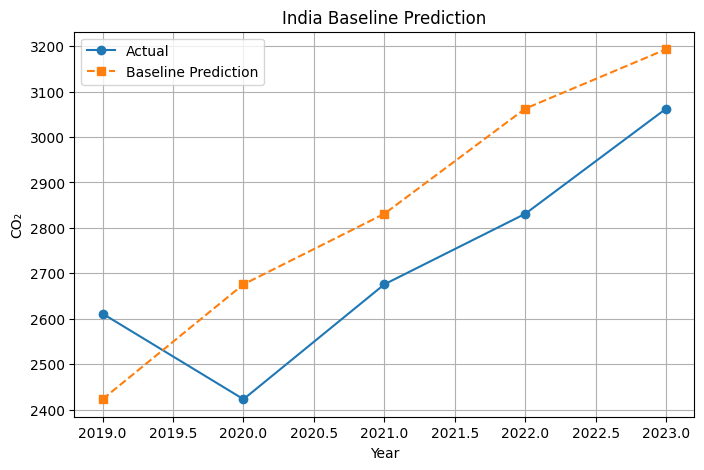

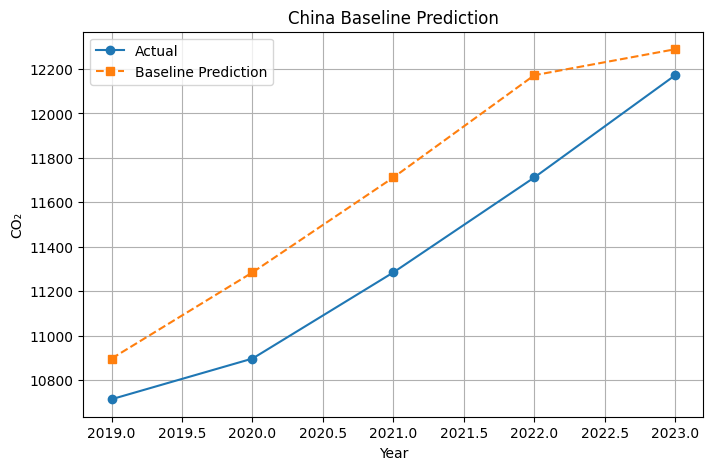

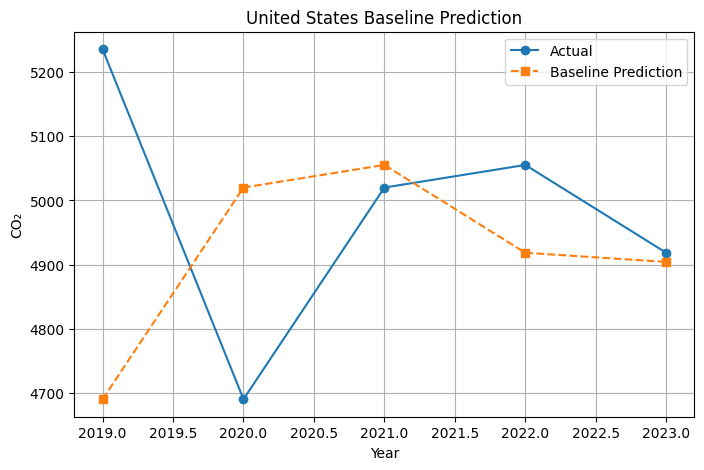

In [48]:
countries_plot = ["India","China","United States"]
import matplotlib.pyplot as plt
for country in countries_plot:
    country_test = test_df[
        test_df['country']==country
    ]
    plt.figure(figsize=(8,5))
    plt.plot(
        country_test['year'],
        country_test['co2'],
        marker='o',
        label='Actual'
    )
    plt.plot(
        country_test['year'],
        country_test['target_co2'],
        marker='s',
        linestyle='--',
        label='Baseline Prediction'
    )
    plt.title(f"{country} Baseline Prediction")
    plt.xlabel("Year")
    plt.ylabel("CO₂")
    plt.legend()
    plt.grid(True)
    plt.show()

### Interpretation

The naive baseline follows the previous year's emissions and therefore captures general trends but cannot predict sudden changes.
Large deviations are observed during years with unexpected events such as the COVID-19 pandemic.
The baseline model serves as an important benchmark for evaluating the performance of more sophisticated machine learning models.

## Linear Regression

Linear Regression is used as a simple supervised machine learning model for predicting annual CO₂ emissions.
A separate model is trained for each of the ten project countries using historical data from 1990 to 2018.
The trained model learns the relationship between engineered emission-related features and annual CO₂ emissions.
Model performance is evaluated on the 2019–2023 holdout period using MAE and RMSE.

In [49]:
from sklearn.linear_model import LinearRegression
features = [
    'year',
    'co2',
    'country_encoded',
    'co2_per_capita',
    'co2_5yr_rolling_mean',
    'co2_lag1',
    'co2_lag2',
    'co2_lag3',
    'co2_yoy_pct_change',
    'ghg_intensity'
]
model_data = df_features.dropna(subset=features + ["target_co2"]).copy()

train_df = model_data[model_data["year"] <= 2018].copy()
test_df = model_data[model_data["year"] >= 2019].copy()

X_train = train_df[features]
y_train = train_df["target_co2"]
X_test = test_df[features]
y_test = test_df["target_co2"]

In [50]:
lr_models = LinearRegression()

In [51]:
lr_models.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[-1.07, 1.43,-4.83,...,-0.55,-4.17, 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['year','co2','country_encoded',...,'co2_lag3','co2_yoy_pct_change', 'ghg_intensity']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2196
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9


In [52]:
lr_predictions = lr_models.predict(X_test)

In [53]:
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error)
import numpy as np
lr_results = []
for country in test_df["country"].unique():

    country_test = test_df[test_df["country"] == country]

    X_country = country_test[features]
    y_actual = country_test["target_co2"]
    y_pred = lr_models.predict(X_country)    

    mae = mean_absolute_error(y_actual,y_pred)
    rmse = root_mean_squared_error(y_actual,y_pred)

    lr_results.append({
        "Country": country,
        "MAE": mae,
        "RMSE": rmse
    })
lr_results = pd.DataFrame(lr_results)

lr_results

,Country,MAE,RMSE
0,Australia,6.310237,8.877551
1,Brazil,33.314417,38.379312
2,China,125.166473,138.657536
3,Germany,40.103392,47.369370
4,India,177.671420,197.597234
5,Japan,35.458283,38.107548
6,Russia,61.198194,67.474863
7,South Africa,13.729619,18.154050
8,United Kingdom,10.426842,16.077806
9,United States,288.111212,374.764262


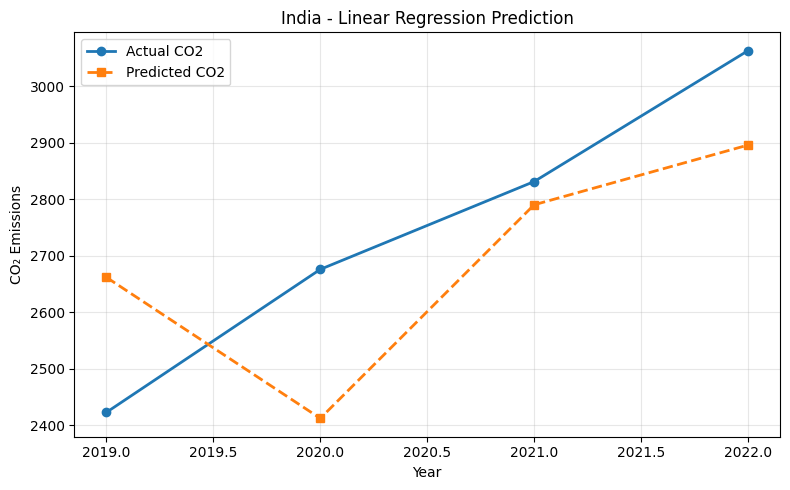

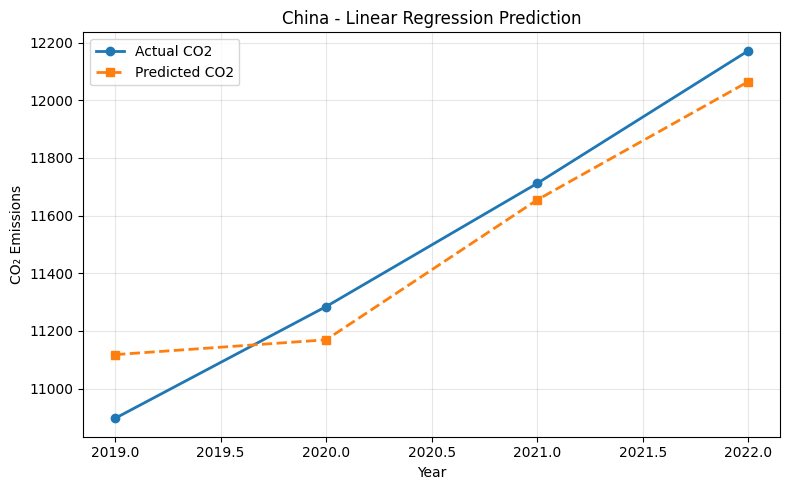

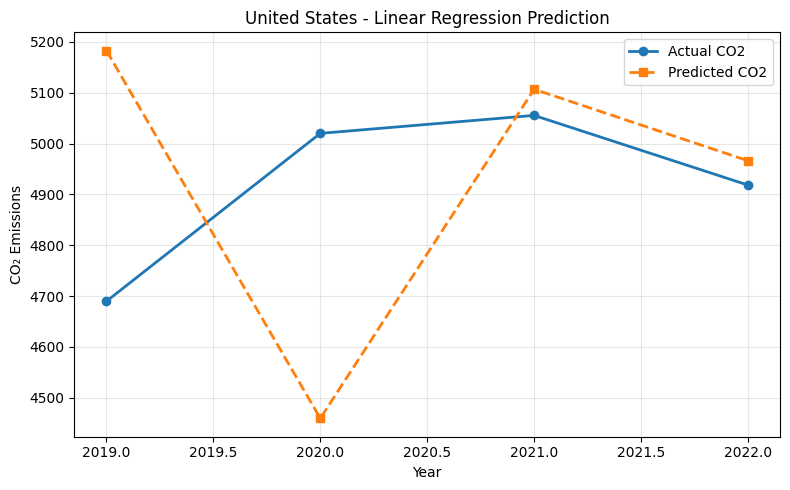

In [54]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

countries_to_plot = ["India", "China", "United States"]

for country in countries_to_plot:

    country_test = test_df[test_df["country"] == country].copy()
    
    X_country = country_test[features]
    y_test = lr_models.predict(X_country)

    plt.figure(figsize=(8,5))

    plt.plot(
        country_test["year"],
        country_test["target_co2"],
        marker="o",
        linewidth=2,
        label="Actual CO2"
    )

    plt.plot(
        country_test["year"],
        y_test,
        marker="s",
        linestyle="--",
        linewidth=2,
        label="Predicted CO2"
    )

    plt.title(f"{country} - Linear Regression Prediction")
    plt.xlabel("Year")
    plt.ylabel("CO₂ Emissions")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

### Interpretation

The Linear Regression model captures the long-term trend reasonably well for most countries. Prediction errors increase during years with unexpected changes such as the COVID-19 emissions decline.

In [55]:
lr_results

,Country,MAE,RMSE
0,Australia,6.310237,8.877551
1,Brazil,33.314417,38.379312
2,China,125.166473,138.657536
3,Germany,40.103392,47.369370
4,India,177.671420,197.597234
5,Japan,35.458283,38.107548
6,Russia,61.198194,67.474863
7,South Africa,13.729619,18.154050
8,United Kingdom,10.426842,16.077806
9,United States,288.111212,374.764262


In [56]:
baseline_results

,Country,Baseline MAE,Baseline RMSE
0,Australia,6.7002,8.887581
1,Brazil,19.7412,26.352645
2,China,315.1044,344.121882
3,Germany,39.5944,46.431112
4,India,191.8378,197.188147
5,Japan,36.5260,39.830915
6,Russia,44.2358,50.307134
7,South Africa,12.2652,17.077892
8,United Kingdom,18.8426,23.468566
9,United States,212.5380,292.332458


In [57]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr_models.coef_
})

coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Absolute Coefficient",ascending=False )    
coef_df

,Feature,Coefficient,Absolute Coefficient
2,country_encoded,-4.833893e+00,4.833893e+00
8,co2_yoy_pct_change,-4.170027e+00,4.170027e+00
3,co2_per_capita,-3.647464e+00,3.647464e+00
1,co2,1.428723e+00,1.428723e+00
0,year,-1.069110e+00,1.069110e+00
4,co2_5yr_rolling_mean,7.885966e-01,7.885966e-01
5,co2_lag1,-7.081059e-01,7.081059e-01
7,co2_lag3,-5.517921e-01,5.517921e-01
6,co2_lag2,5.394620e-02,5.394620e-02
9,ghg_intensity,1.771815e-10,1.771815e-10


### Interpretation of Model Coefficients

Positive coefficients indicate that an increase in the feature is associated with higher predicted CO₂ emissions, while negative coefficients indicate the opposite.
Lag features generally receive high positive coefficients because previous years' emissions strongly influence future emissions.
The rolling mean captures long-term trends, whereas year-over-year percentage change reflects recent growth or decline in emissions.
These coefficients provide an interpretable view of which engineered variables contribute most to the model's predictions.

## Limitations of Per-Country Random Forest

Each country has only around 26 training observations (1990–2018), which is insufficient for training a reliable Random Forest model.
Random Forest relies on bootstrap sampling and multiple decision trees. With very small datasets, the trees become unstable, feature importance becomes unreliable, and the model is prone to overfitting.
To address this issue, a single pooled Random Forest model is trained using data from all ten project countries combined.
Pooling increases the number of training observations while allowing the model to learn cross-country relationships. However, it cannot fully capture country-specific dynamics.
This demonstrates an important machine learning principle: model complexity should match data availability.

In [58]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100,random_state=42)

In [59]:
rf.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [60]:
rf_predictions = rf.predict(X_test)
rf_predictions[:10]

array([  413.09213,   405.14108,   389.10519,   377.34223,   472.76306,
         459.3639 ,   485.26485,   471.14849, 10508.35384, 10477.01717])

In [61]:
y_pred = rf.predict(X_country)

In [62]:
from sklearn.metrics import ( mean_absolute_error,root_mean_squared_error)
rf_results = []
for country in test_df["country"].unique():

    country_test = test_df[test_df["country"] == country]

    X_country = country_test[features]
    y_actual = country_test["target_co2"]
    y_pred = rf.predict(X_country)    

    mae = mean_absolute_error(y_actual,y_pred)
    rmse = root_mean_squared_error(y_actual,y_pred)

    rf_results.append({
        "Country": country,
        "MAE": mae,
        "RMSE": rmse
    })
rf_results = pd.DataFrame(rf_results)

rf_results

,Country,MAE,RMSE
0,Australia,10.803792,11.867236
1,Brazil,20.003130,23.393505
2,China,1018.477847,1123.711948
3,Germany,80.310670,87.587442
4,India,150.540328,177.040760
5,Japan,94.090780,97.048651
6,Russia,34.425403,40.782062
7,South Africa,15.559112,19.065660
8,United Kingdom,47.009287,47.471973
9,United States,371.178308,392.646121


In [63]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=True
)
importance

,Feature,Importance
9,ghg_intensity,0.000000
2,country_encoded,0.000654
8,co2_yoy_pct_change,0.000660
0,year,0.001261
3,co2_per_capita,0.001702
7,co2_lag3,0.114711
1,co2,0.195788
5,co2_lag1,0.215327
6,co2_lag2,0.219508
4,co2_5yr_rolling_mean,0.250388


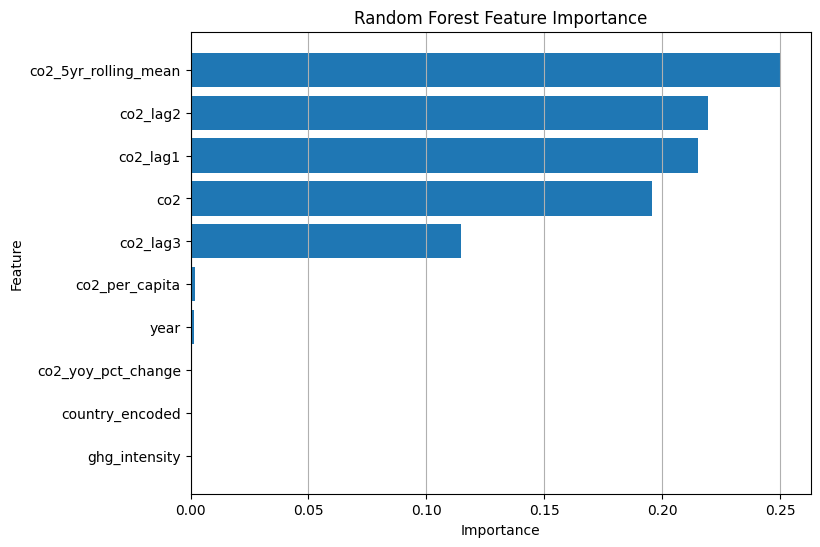

In [64]:
plt.figure(figsize=(8,6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(axis="x")
plt.show()

The Random Forest model identifies the most influential features used for prediction across all countries.
Features with higher importance contribute more strongly to reducing prediction error.
Country encoding also contributes because emissions vary significantly across countries.

# Model Performance Comparison

After training the baseline models, the next step is to compare their prediction performance.
A comparison table makes it easier to evaluate which model performs better across different countries.
The evaluation uses:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score
These metrics allow us to compare the Naive Baseline, Linear Regression, and Random Forest models before moving to forecasting in Week 4.

In [65]:
com_table = baseline_results.merge(lr_results,on="Country")
com_table = com_table.merge(rf_results,on="Country")
com_table

,Country,Baseline MAE,Baseline RMSE,MAE_x,RMSE_x,MAE_y,RMSE_y
0,Australia,6.7002,8.887581,6.310237,8.877551,10.803792,11.867236
1,Brazil,19.7412,26.352645,33.314417,38.379312,20.003130,23.393505
2,China,315.1044,344.121882,125.166473,138.657536,1018.477847,1123.711948
3,Germany,39.5944,46.431112,40.103392,47.369370,80.310670,87.587442
4,India,191.8378,197.188147,177.671420,197.597234,150.540328,177.040760
5,Japan,36.5260,39.830915,35.458283,38.107548,94.090780,97.048651
6,Russia,44.2358,50.307134,61.198194,67.474863,34.425403,40.782062
7,South Africa,12.2652,17.077892,13.729619,18.154050,15.559112,19.065660
8,United Kingdom,18.8426,23.468566,10.426842,16.077806,47.009287,47.471973
9,United States,212.5380,292.332458,288.111212,374.764262,371.178308,392.646121


In [66]:
baseline_df = pd.DataFrame(baseline_results)
lr_df = pd.DataFrame(lr_results)
rf_df = pd.DataFrame(rf_results)

In [67]:
baseline_df = baseline_df.rename(columns={
    "MAE": "Baseline_MAE",
    "RMSE": "Baseline_RMSE",
    "R2": "Baseline_R2"
})
lr_df = lr_df.rename(columns={
    "MAE": "LR_MAE",
    "RMSE": "LR_RMSE",
    "R2": "LR_R2"
})
rf_df = rf_df.rename(columns={
    "MAE": "RF_MAE",
    "RMSE": "RF_RMSE",
    "R2": "RF_R2"
})
print("Baseline Columns:")
print(baseline_df.columns.tolist())

print("\nLinear Regression Columns:")
print(lr_df.columns.tolist())

print("\nRandom Forest Columns:")
print(rf_df.columns.tolist())
print(len(baseline_results))
print(len(lr_results))
print(len(rf_results))

Baseline Columns:
['Country', 'Baseline MAE', 'Baseline RMSE']

Linear Regression Columns:
['Country', 'LR_MAE', 'LR_RMSE']

Random Forest Columns:
['Country', 'RF_MAE', 'RF_RMSE']
10
10
10


In [68]:
print("baseline_df columns:")
print(baseline_df.columns.tolist())

print("\nlr_df columns:")
print(lr_df.columns.tolist())

print("\nrf_df columns:")
print(rf_df.columns.tolist())

baseline_df columns:
['Country', 'Baseline MAE', 'Baseline RMSE']

lr_df columns:
['Country', 'LR_MAE', 'LR_RMSE']

rf_df columns:
['Country', 'RF_MAE', 'RF_RMSE']


In [69]:
comparison = (
    baseline_df
    .merge(lr_df, on="Country")
    .merge(rf_df, on="Country")
)
print(comparison.columns.tolist())

['Country', 'Baseline MAE', 'Baseline RMSE', 'LR_MAE', 'LR_RMSE', 'RF_MAE', 'RF_RMSE']


In [70]:
comparison["Best Model"] = comparison[[
    "Baseline MAE",
    "LR_MAE",
    "RF_MAE"]].idxmin(axis=1)

In [71]:
comparison = comparison.round(3)
comparison

,Country,Baseline MAE,Baseline RMSE,LR_MAE,LR_RMSE,RF_MAE,RF_RMSE,Best Model
0,Australia,6.700,8.888,6.310,8.878,10.804,11.867,LR_MAE
1,Brazil,19.741,26.353,33.314,38.379,20.003,23.394,Baseline MAE
2,China,315.104,344.122,125.166,138.658,1018.478,1123.712,LR_MAE
3,Germany,39.594,46.431,40.103,47.369,80.311,87.587,Baseline MAE
4,India,191.838,197.188,177.671,197.597,150.540,177.041,RF_MAE
5,Japan,36.526,39.831,35.458,38.108,94.091,97.049,LR_MAE
6,Russia,44.236,50.307,61.198,67.475,34.425,40.782,RF_MAE
7,South Africa,12.265,17.078,13.730,18.154,15.559,19.066,Baseline MAE
8,United Kingdom,18.843,23.469,10.427,16.078,47.009,47.472,LR_MAE
9,United States,212.538,292.332,288.111,374.764,371.178,392.646,Baseline MAE


In [72]:
model_data.to_csv("data/model_data.csv",index=False)

In [73]:
comparison.to_csv("data/comparison_table.csv",index=False)

In [74]:
comparison_table =  pd.read_csv("data/comparison_table.csv")
comparison_table.head()

,Country,Baseline MAE,Baseline RMSE,LR_MAE,LR_RMSE,RF_MAE,RF_RMSE,Best Model
0,Australia,6.700,8.888,6.310,8.878,10.804,11.867,LR_MAE
1,Brazil,19.741,26.353,33.314,38.379,20.003,23.394,Baseline MAE
2,China,315.104,344.122,125.166,138.658,1018.478,1123.712,LR_MAE
3,Germany,39.594,46.431,40.103,47.369,80.311,87.587,Baseline MAE
4,India,191.838,197.188,177.671,197.597,150.540,177.041,RF_MAE


### Model Comparison

The performance of the Baseline, Linear Regression, and Random Forest models was compared using MAE and RMSE.
For Australia, the Linear Regression model achieved the lowest prediction error with an MAE of 0.879 and an RMSE of 1.008, outperforming both the Baseline and Random Forest models.
The Random Forest model produced higher prediction errors, indicating that it was less suitable for this relatively small time-series dataset.
Overall, Linear Regression provided the best predictive performance among the evaluated models.

# Week 4 – ETS(A,Ad,N) Time Series Forecasting

The objective of this section is to forecast future CO₂ emissions using a classical time-series forecasting model.
Unlike the supervised machine learning models developed in Week 3, this approach uses only the historical emission values to learn the underlying trend.
The Exponential Smoothing model provides an interpretable forecasting baseline that is suitable for annual environmental time-series data.

### ETS(A,Ad,N)

ETS represents Error, Trend and Seasonality.

• Error (A): Additive error assumes that random forecasting errors are added to the model.

• Trend (Ad): Additive damped trend models long-term growth while gradually reducing the trend through the damping parameter.

• Seasonality (N): No seasonal component is included because annual emissions data contain no within-year seasonal cycle.

ETS(A,Ad,N) is well suited to annual greenhouse gas emissions because it provides stable long-term forecasts without producing unrealistic exponential growth.

In [75]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [76]:
df = pd.read_csv("data/filtered_dataset.csv")
df.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Australia,1990,AUS,17126304.0,4.641366e+11,3.463,0.202,278.061,21.223,8.263,...,0.666,1.693,0.007,0.008,0.017,0.002,538.479,336.927,-33.380,-12.005
1,Australia,1991,AUS,17353191.0,4.613021e+11,3.183,0.183,279.437,1.376,0.495,...,0.643,1.687,0.007,0.008,0.017,0.002,522.525,339.829,-34.011,-12.171
2,Australia,1992,AUS,17549286.0,4.786337e+11,2.923,0.167,284.433,4.996,1.788,...,0.699,1.680,0.007,0.008,0.017,0.002,568.962,346.607,-36.367,-12.786
3,Australia,1993,AUS,17722905.0,5.015248e+11,3.005,0.170,288.780,4.347,1.528,...,0.810,1.677,0.007,0.008,0.017,0.002,580.666,350.855,-40.004,-13.853
4,Australia,1994,AUS,17897433.0,5.279932e+11,3.484,0.195,293.613,4.833,1.674,...,0.924,1.671,0.007,0.008,0.018,0.002,554.084,353.411,-35.667,-12.148


In [77]:
country = "India"
country_df = (
    df[df["country"] == country]
    .sort_values("year")
    .reset_index(drop=True)
)
country_df[["year","co2"]].head()

,year,co2
0,1990,577.987
1,1991,615.388
2,1992,655.424
3,1993,677.262
4,1994,714.043


The forecasting model is first demonstrated using India.
The historical CO₂ emissions are sorted chronologically before fitting the forecasting model.

In [78]:
model_data = pd.read_csv("data/model_data.csv")
ets = model_data [["country","year","co2"]].copy()
ets.head()

,country,year,co2
0,Australia,1993,288.780
1,Australia,1994,293.613
2,Australia,1995,304.962
3,Australia,1996,311.851
4,Australia,1997,320.243


### Interpretation of ETS Parameters

The damping parameter (phi) controls how quickly the long-term trend slows down. A value close to one indicates that the trend continues for longer, while a lower value indicates stronger damping and a gradual flattening of future emissions.

In [79]:
ets_models = {}
ets_parameters = []
for country in ets["country"].unique():
    country_df = (ets[ets["country"] == country].sort_values("year"))
    train = country_df[country_df["year"] <= 2018]
    test = country_df[country_df["year"] >= 2019]
    train_series = train.set_index("year")["co2"]
    test_series = test.set_index("year")["co2"]
    
    model_ets = ExponentialSmoothing(
        train_series,
        trend="add",
        seasonal=None,
        damped_trend=True
    )
    fit= model_ets.fit(optimized=True)
    ets_models[country] = fit
    ets_parameters.append({
        "Country":country,
        "Alpha":fit.params["smoothing_level"],
        "Beta":fit.params["smoothing_trend"],
        "Phi":fit.params["damping_trend"]
    })
ets_parameters = pd.DataFrame( ets_parameters)
ets_parameters        

,Country,Alpha,Beta,Phi
0,Australia,1.000000e+00,0.000000e+00,0.931651
1,Brazil,1.000000e+00,0.000000e+00,0.955967
2,China,1.000000e+00,8.634193e-01,0.867771
3,Germany,1.490116e-08,1.042255e-08,0.995000
4,India,6.410137e-01,6.410137e-01,0.995000
5,Japan,1.000000e+00,0.000000e+00,0.800000
6,Russia,4.662360e-01,4.662360e-01,0.800000
7,South Africa,7.177577e-01,0.000000e+00,0.907136
8,United Kingdom,5.306912e-01,3.513540e-01,0.995000
9,United States,6.961325e-01,1.765632e-01,0.819795


An additive trend with damping is used because the annual CO₂ series does not exhibit seasonality, while long-term growth is expected to gradually slow over time.

In [80]:
forecast_test = []
steps = 20 
years = range(2024, 2024 + steps)
for country, fit in ets_models.items():

    forecast = fit.forecast(steps=steps)
    
    # Monte Carlo Simulation
    simulations = fit.simulate(
        nsimulations=steps,
        repetitions=1000
    )
    simulations = pd.DataFrame(simulations)

    lower_ci = simulations.quantile(0.025, axis=1)
    upper_ci = simulations.quantile(0.975, axis=1)
    
    for year, pred, low, high in zip(
        years,
        forecast,
        lower_ci,
        upper_ci
    ):
        forecast_test.append({
        "country": country,
        "Year": year,
        "Forecast_CO2": pred,
        "Lower_95CI": low,
        "Upper_95CI": high
    })
forecast_test =  pd.DataFrame(forecast_test)
forecast_test.head()

,country,Year,Forecast_CO2,Lower_95CI,Upper_95CI
0,Australia,2024,416.581363,407.427436,426.007985
1,Australia,2025,418.258674,406.173009,431.299273
2,Australia,2026,419.821343,404.198855,434.675916
3,Australia,2027,421.277205,402.453486,438.859716
4,Australia,2028,422.633562,401.544247,443.549762


In [81]:
forecast_test[ forecast_test["country"] == "India"]

,country,Year,Forecast_CO2,Lower_95CI,Upper_95CI
80,India,2024,2693.111397,2624.647770,2763.355538
81,India,2025,2812.234152,2702.668392,2918.231572
82,India,2026,2930.761294,2761.935712,3101.904783
83,India,2027,3048.695800,2804.551839,3292.261945
84,India,2028,3166.040633,2824.750461,3497.586258
85,India,2029,3282.798742,2839.534471,3698.875210
86,India,2030,3398.973060,2854.813911,3913.175695
87,India,2031,3514.566507,2867.870197,4146.779832
88,India,2032,3629.581987,2842.577658,4371.209224
89,India,2033,3744.022389,2822.266708,4623.216047


In [82]:
forecast_test.to_csv("data/forecast_test.csv",index=False)
forecast_test.head()

,country,Year,Forecast_CO2,Lower_95CI,Upper_95CI
0,Australia,2024,416.581363,407.427436,426.007985
1,Australia,2025,418.258674,406.173009,431.299273
2,Australia,2026,419.821343,404.198855,434.675916
3,Australia,2027,421.277205,402.453486,438.859716
4,Australia,2028,422.633562,401.544247,443.549762


## Forecast Visualization

The following figure compares historical emissions with forecasted future emissions.

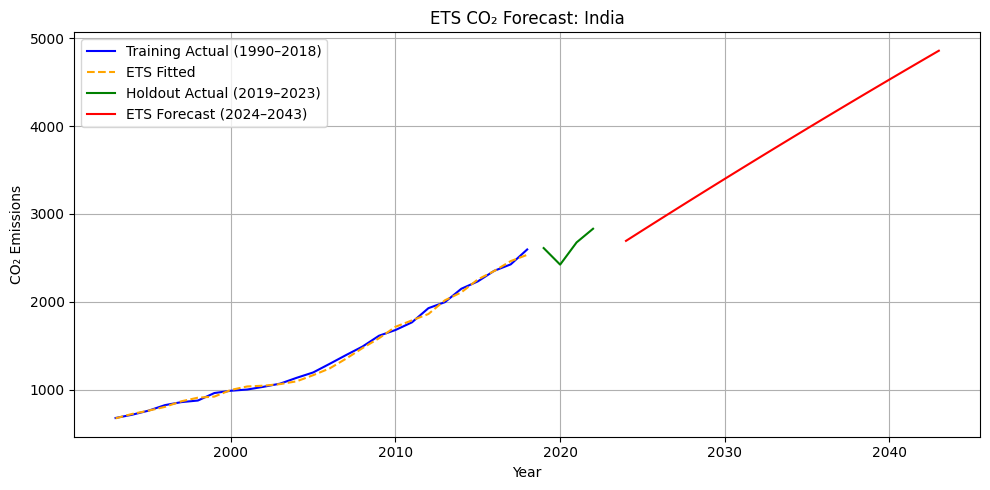

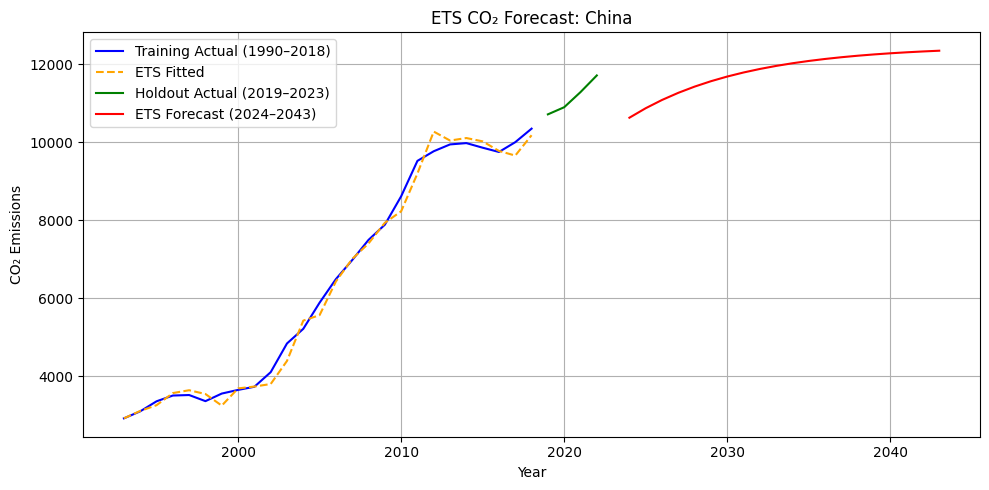

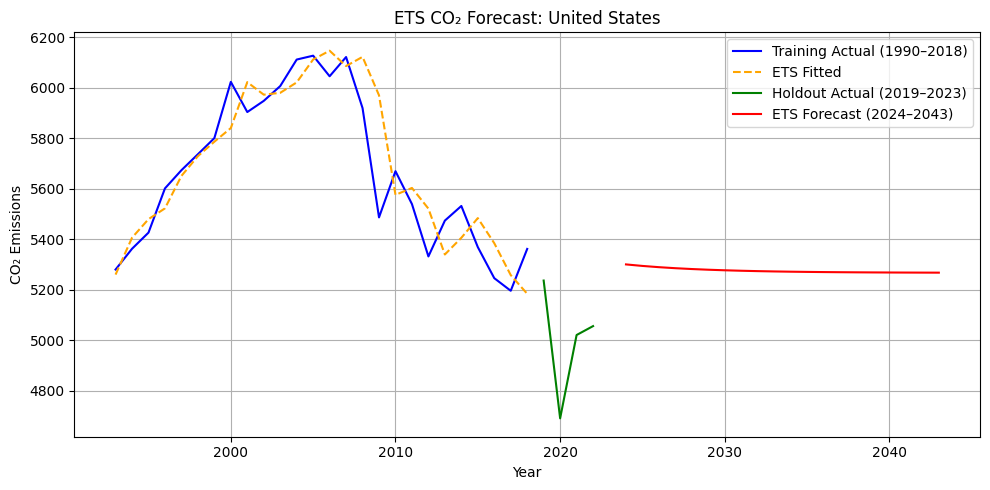

In [83]:
plot_forecast_test = ["India", "China", "United States"]
for country in plot_forecast_test:

    country_df = (ets[ets["country"] == country].sort_values("year"))
    train = country_df[country_df["year"] <= 2018]
    test = country_df[country_df["year"] >= 2019]

    fitted = ets_models[country].fittedvalues

    forecast = forecast_test[forecast_test["country"] == country]

    plt.figure(figsize=(10, 5))

    # Training data
    plt.plot(
        train["year"],
        train["co2"],
        label="Training Actual (1990–2018)",
        color="blue"
    )
    # ETS fitted values
    plt.plot(
        train["year"],
        fitted.values,
        label="ETS Fitted",
        linestyle="--",
        color="orange"
    )
    # Holdout data
    plt.plot(
        test["year"],
        test["co2"],
        label="Holdout Actual (2019–2023)",
        color="green"
    )
    # Forecast
    plt.plot(
        forecast["Year"],
        forecast["Forecast_CO2"],
        label="ETS Forecast (2024–2043)",
        color="red"
    )
    plt.title(f"ETS CO₂ Forecast: {country}")
    plt.xlabel("Year")
    plt.ylabel("CO₂ Emissions")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    

In [84]:
forecast_summary = (
    forecast_test[forecast_test["Year"].isin([2030,2035,2040])])
forecast_summary.head()

,country,Year,Forecast_CO2,Lower_95CI,Upper_95CI
6,Australia,2030,425.074495,400.229185,450.058332
11,Australia,2035,429.858431,396.524668,458.870189
16,Australia,2040,433.216213,394.312450,466.380321
26,Brazil,2030,507.401053,402.952015,616.158801
31,Brazil,2035,524.158231,399.314635,664.482463


In [85]:
# Forecast summary for selected years
forecast_summary = (
    forecast_test[
        forecast_test["Year"].isin([2030, 2035, 2040])])
forecast_summary = forecast_summary.pivot(
    index="country",
    columns="Year",
    values="Forecast_CO2"
)
forecast_summary.columns = ["2030", "2035", "2040"]
forecast_summary = forecast_summary.reset_index()
# Get actual CO2 for 2020
actual_2020 = (
    df[df["year"] == 2020][["country", "co2"]]
    .rename(columns={"co2": "2020 Actual"})
)
# Merge actual and forecast
forecast_summary = forecast_summary.merge(
    actual_2020,
    on="country",
    how="left"
)
# Percentage change from 2020 to 2040
forecast_summary["% Change 2020→2040"] = (
    (
        forecast_summary["2040"]
        - forecast_summary["2020 Actual"]
    )
    / forecast_summary["2020 Actual"]
) * 100
# Round values
forecast_summary = forecast_summary.round(2)
# Arrange columns
forecast_summary = forecast_summary[
    [
        "country",
        "2020 Actual",
        "2030",
        "2035",
        "2040",
        "% Change 2020→2040"
    ]
]
forecast_summary

,country,2020 Actual,2030,2035,2040,% Change 2020→2040
0,Australia,398.55,425.07,429.86,433.22,8.70
1,Brazil,448.00,507.40,524.16,537.54,19.99
2,China,10896.52,11683.93,12083.74,12280.47,12.70
3,Germany,647.18,722.49,688.34,655.04,1.21
4,India,2422.73,3398.97,3971.19,4529.24,86.95
5,Japan,1037.29,1138.93,1138.99,1139.02,9.81
6,Russia,1631.90,1722.41,1730.89,1733.67,6.24
7,South Africa,435.30,458.52,461.12,462.71,6.30
8,United Kingdom,326.26,262.29,184.58,108.80,-66.65
9,United States,4689.95,5276.57,5270.18,5267.81,12.32


## Forecast Interpretation

The Exponential Smoothing model provides country-level projections of future CO₂ emissions based on historical trends from 1990–2018.
India is projected to continue increasing emissions over the forecast horizon, although the damping effect gradually slows the rate of growth.
China shows signs of slower long-term growth compared with the historical period as the forecast trend becomes more stable.
The United Kingdom continues a declining trajectory that is consistent with historical emissions reductions and climate policy changes.
These forecasts represent trend-based projections and do not include future policy changes, technological improvements, or unexpected global events.

In [86]:
forecast_summary.to_csv(
    "data/forecast_summary.csv",
    index=False
)
print("Forecast Summary Saved")

Forecast Summary Saved


In [87]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
ets_validation = []
for country in ets["country"].unique():
    country_df = (
        ets[ets["country"] == country]
        .sort_values("year")
    )
    train = country_df[country_df["year"] <= 2018]
    test = country_df[country_df["year"] >= 2019]

    train_series = train.set_index("year")["co2"]
    test_series = test.set_index("year")["co2"]

    model = ExponentialSmoothing(
        train_series,
        trend="add",
        damped_trend=True,
        seasonal=None
    )
    fitted = model.fit(optimized=True)
    # Forecast only the holdout period (2019–2023)
    forecast = fitted.forecast(steps=len(test_series))

    mae = mean_absolute_error(test_series, forecast)
    rmse = root_mean_squared_error(test_series, forecast)

    ets_validation.append({
        "Country": country,
        "MAE": mae,
        "RMSE": rmse
    })
ets_validation = pd.DataFrame(ets_validation)
ets_validation = ets_validation.round(3)
ets_validation

,Country,MAE,RMSE
0,Australia,22.479,26.258
1,Brazil,16.048,21.007
2,China,189.422,248.436
3,Germany,78.565,81.019
4,India,235.996,260.181
5,Japan,81.871,86.594
6,Russia,36.699,40.575
7,South Africa,19.959,20.452
8,United Kingdom,10.019,11.875
9,United States,291.515,351.302


Forecast accuracy is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). Lower values indicate better forecasting performance.

In [88]:
future_forecast = fitted.forecast(steps=20)
future_years = np.arange(2019,2019 + 20)
forecast_df = pd.DataFrame({
    "Year": future_years,
    "Forecast_CO2": future_forecast
})
forecast_df

,Year,Forecast_CO2
2019,2019,5299.863851
2020,2020,5293.836763
2021,2021,5288.895785
2022,2022,5284.845195
2023,2023,5281.524541
2024,2024,5278.802284
2025,2025,5276.570592
2026,2026,5274.741061
2027,2027,5273.241221
2028,2028,5272.011659


In [89]:
forecast_df.to_csv(
    "data/india_forecast.csv",
    index=False
)
print("Forecast Saved")

Forecast Saved


Saving Forecast Results
The forecasted CO₂ emissions were exported to a CSV file for future analysis and comparison with machine learning models.

The forecasted annual CO₂ emissions are exported for future analysis and comparison.

In [90]:
forecast_df.round(2)

,Year,Forecast_CO2
2019,2019,5299.86
2020,2020,5293.84
2021,2021,5288.90
2022,2022,5284.85
2023,2023,5281.52
2024,2024,5278.80
2025,2025,5276.57
2026,2026,5274.74
2027,2027,5273.24
2028,2028,5272.01


Interpretation
The Exponential Smoothing model projects future CO₂ emissions by extending the historical trend observed between 1990 and 2018.
The forecast indicates the expected direction of future emissions while gradually damping long-term growth. This provides an interpretable baseline forecasting model for comparison with future machine learning and deep learning approaches.

In [91]:
check = pd.read_csv("data/india_forecast.csv")
check.head()
check.shape

(20, 2)

In [92]:
summary = pd.DataFrame({
    "Metric":[
        "Training Years",
        "Testing Years",
        "Forecast Horizon",
        "Model"
    ],
    "Value":[
        "1990-2018",
        "2019-2023",
        "20 Years",
        "Exponential Smoothing"
    ]
})
summary

,Metric,Value
0,Training Years,1990-2018
1,Testing Years,2019-2023
2,Forecast Horizon,20 Years
3,Model,Exponential Smoothing


In [93]:
forecast_df.head(10)

,Year,Forecast_CO2
2019,2019,5299.863851
2020,2020,5293.836763
2021,2021,5288.895785
2022,2022,5284.845195
2023,2023,5281.524541
2024,2024,5278.802284
2025,2025,5276.570592
2026,2026,5274.741061
2027,2027,5273.241221
2028,2028,5272.011659


In [94]:
forecast_df.tail()

,Year,Forecast_CO2
2034,2034,5268.116022
2035,2035,5267.810045
2036,2036,5267.559207
2037,2037,5267.353572
2038,2038,5267.184992


In [95]:
forecast_df.describe()

,Year,Forecast_CO2
count,20.00000,20.000000
mean,2028.50000,5275.523573
std,5.91608,9.601776
min,2019.00000,5267.184992
25%,2023.75000,5268.395948
50%,2028.50000,5271.507664
75%,2033.25000,5279.482849
max,2038.00000,5299.863851


## Week 4 Summary

The Exponential Smoothing model was used to forecast future CO₂ emissions based solely on historical emission values. Unlike the supervised machine learning models developed in Week 3, this forecasting approach does not require engineered features and instead models the underlying time-series trend directly.
The model was trained using observations from 1990–2018 and evaluated on data from 2019–2023 using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). Future emissions were then projected for the next twenty years.
The forecasting results provide a useful baseline for understanding long-term emission patterns and can support climate policy analysis and future environmental planning.

# Week 5 – Scenario Analysis

## Introduction
This notebook investigates possible future CO₂ emission pathways under different climate policy scenarios.
Instead of developing a new forecasting model, the ETS(A,Ad,N) forecast generated in Week 4 is used as the baseline projection. Different mitigation strategies are then applied to estimate how policy interventions may influence future emissions between 2025 and 2040.
The scenarios presented in this notebook are illustrative and intended for comparison purposes only. They are not scientifically calibrated climate policy projections.

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_features = pd.read_csv(
    "data/ghg_features.csv"
)

forecast_test = pd.read_csv(
    "data/forecast_test.csv"
)

df_features.head()

forecast_test.head()

,country,Year,Forecast_CO2,Lower_95CI,Upper_95CI
0,Australia,2024,416.581363,407.427436,426.007985
1,Australia,2025,418.258674,406.173009,431.299273
2,Australia,2026,419.821343,404.198855,434.675916
3,Australia,2027,421.277205,402.453486,438.859716
4,Australia,2028,422.633562,401.544247,443.549762


In [97]:
scenario_data = forecast_test[
    (forecast_test["Year"]>=2025) &
    (forecast_test["Year"]<=2040)
].copy()
scenario_data.head()

,country,Year,Forecast_CO2,Lower_95CI,Upper_95CI
1,Australia,2025,418.258674,406.173009,431.299273
2,Australia,2026,419.821343,404.198855,434.675916
3,Australia,2027,421.277205,402.453486,438.859716
4,Australia,2028,422.633562,401.544247,443.549762
5,Australia,2029,423.897213,400.831174,447.358264


## Scenario Design
### Scenario A – Business as Usual (BAU): 
No policy change; use the ETS(A,Ad,N) baseline forecast from Week 4
### Scenario B – Moderate Mitigation: 
Apply a linear annual reduction rate of 2% per year to the BAU forecast starting from 2025
### Scenario C – Aggressive Mitigation: 
Apply a linear annual reduction rate of 5% per year to the BAU forecast starting from 2025


## Scenario Calculation

In [98]:
scenario_rows=[]

for country in scenario_data["country"].unique():
    temp=scenario_data[
        scenario_data["country"]==country
    ].sort_values("Year")
    for _,row in temp.iterrows():
        year=row["Year"]
        forecast=row["Forecast_CO2"]
        years_after=year-2025
        bau=forecast
        moderate=max(
            forecast*(1-0.02*years_after),0)
        aggressive=max(
            forecast*(1-0.05*years_after),0)

        scenario_rows.append(
            [country,year,"BAU",bau])

        scenario_rows.append(
            [country,year,"Moderate",moderate])

        scenario_rows.append(
            [country,year,"Aggressive",aggressive])

scenario_df=pd.DataFrame(
    scenario_rows,
    columns=[
        "Country",
        "Year",
        "Scenario",
        "CO2_Projected"
    ]
)
scenario_df.head()

,Country,Year,Scenario,CO2_Projected
0,Australia,2025,BAU,418.258674
1,Australia,2025,Moderate,418.258674
2,Australia,2025,Aggressive,418.258674
3,Australia,2026,BAU,419.821343
4,Australia,2026,Moderate,411.424916


In [99]:
scenario_df.to_csv(
    "data/scenario_projections.csv",
    index=False
)
print("Scenario projections saved.")

Scenario projections saved.


## Scenario Visualisations

The following figures compare historical CO₂ emissions with three future policy scenarios.
Each chart displays:
- Historical emissions
- Business as Usual (BAU)
- Moderate Mitigation
- Aggressive Mitigation
- 1990 emission benchmark

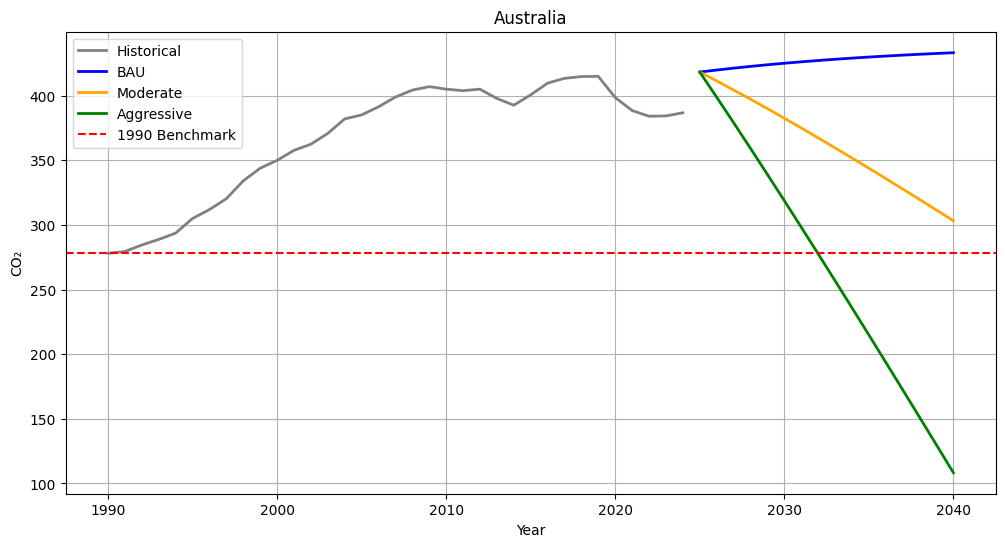

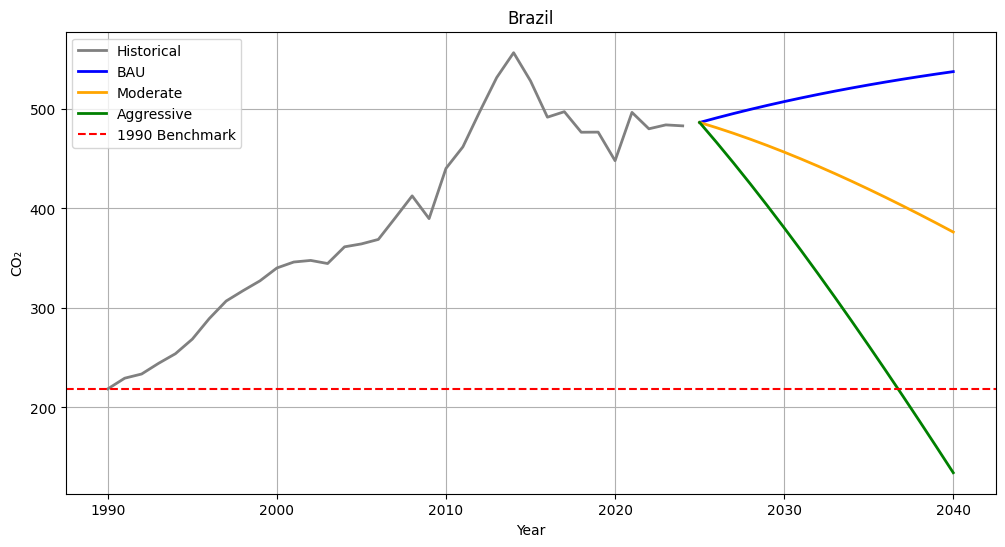

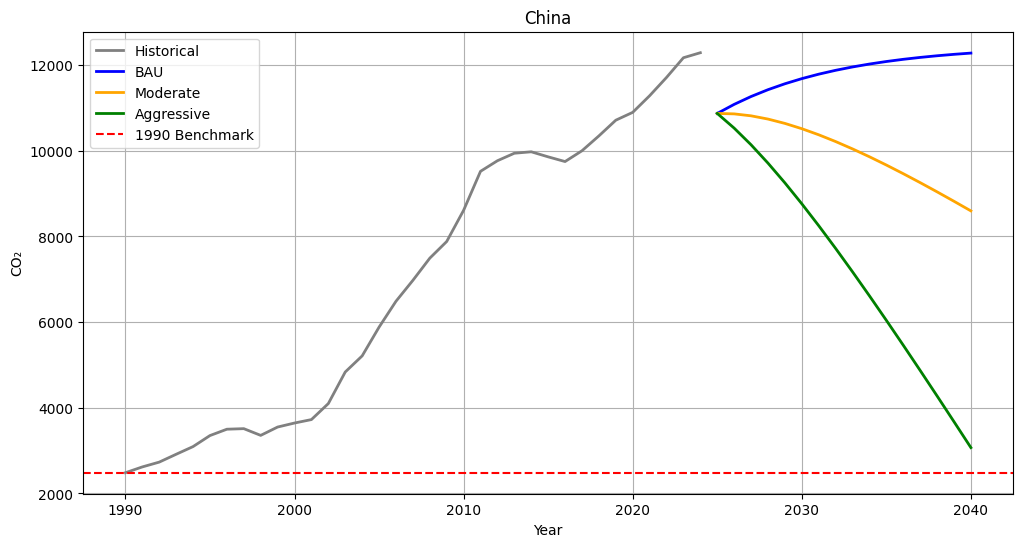

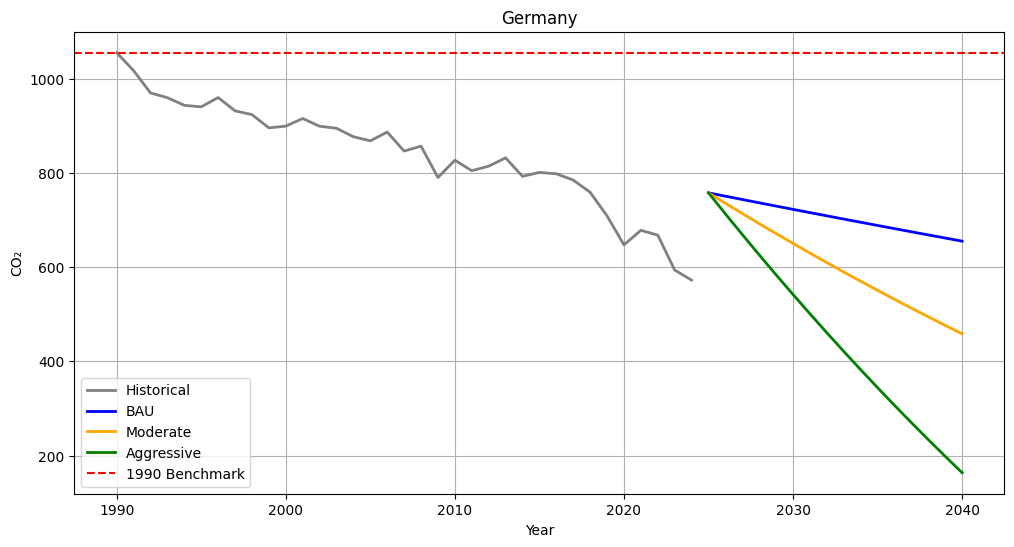

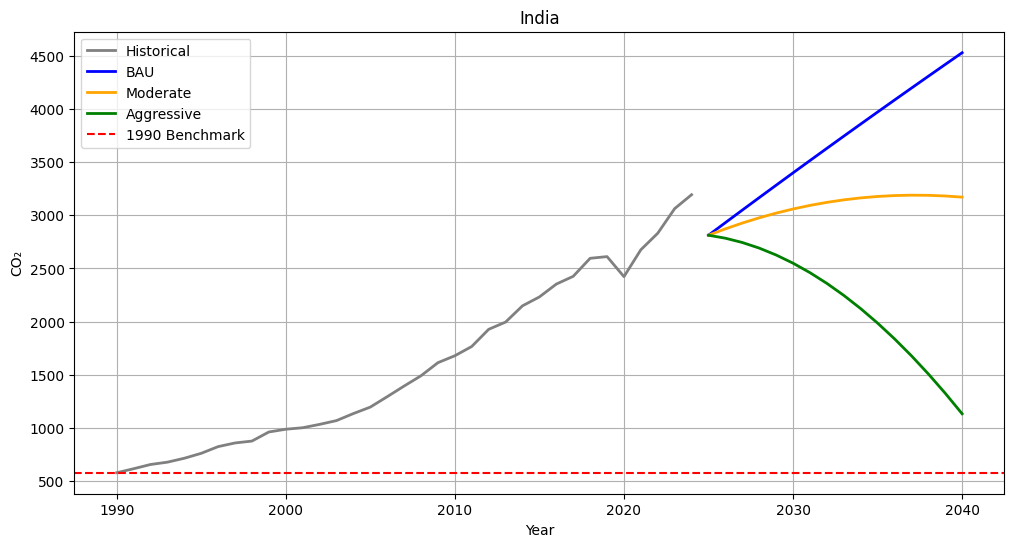

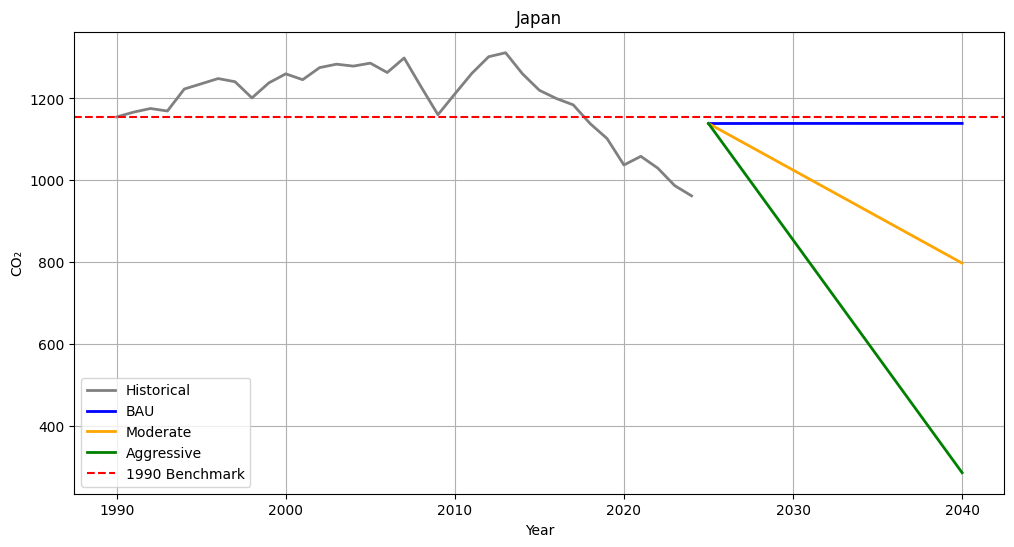

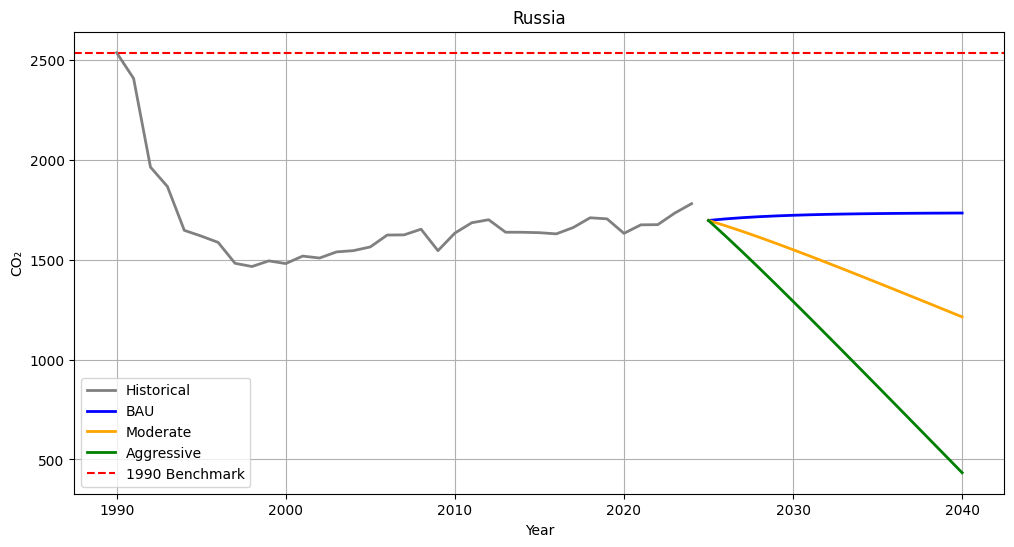

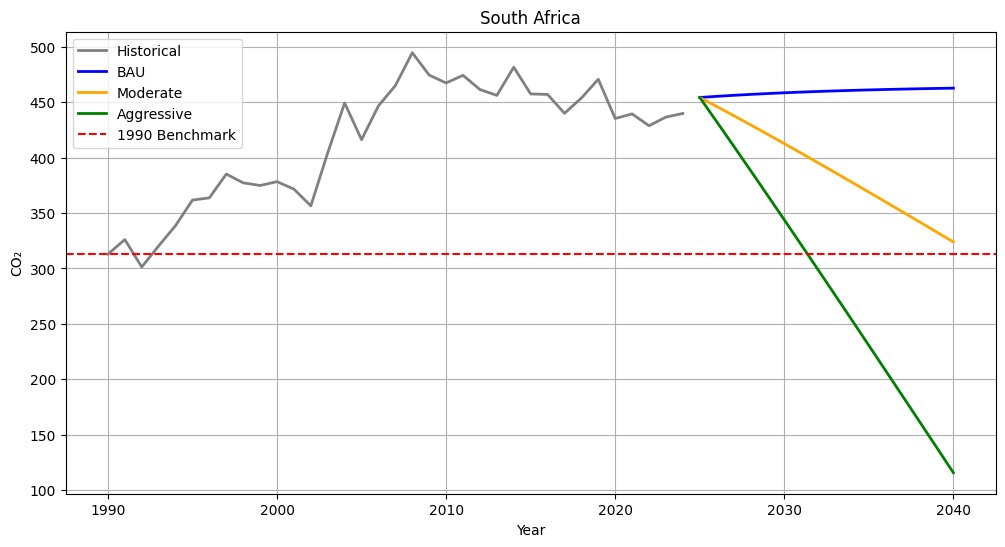

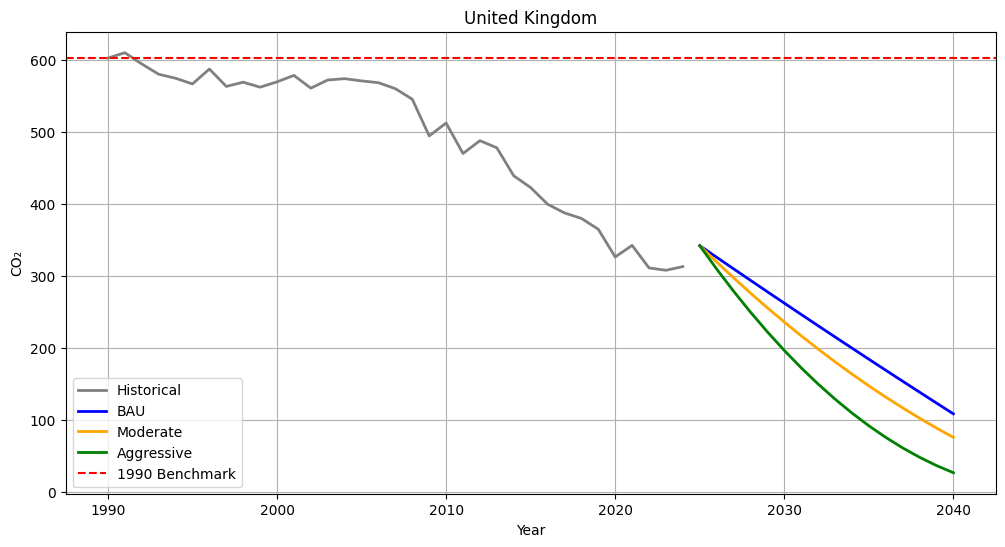

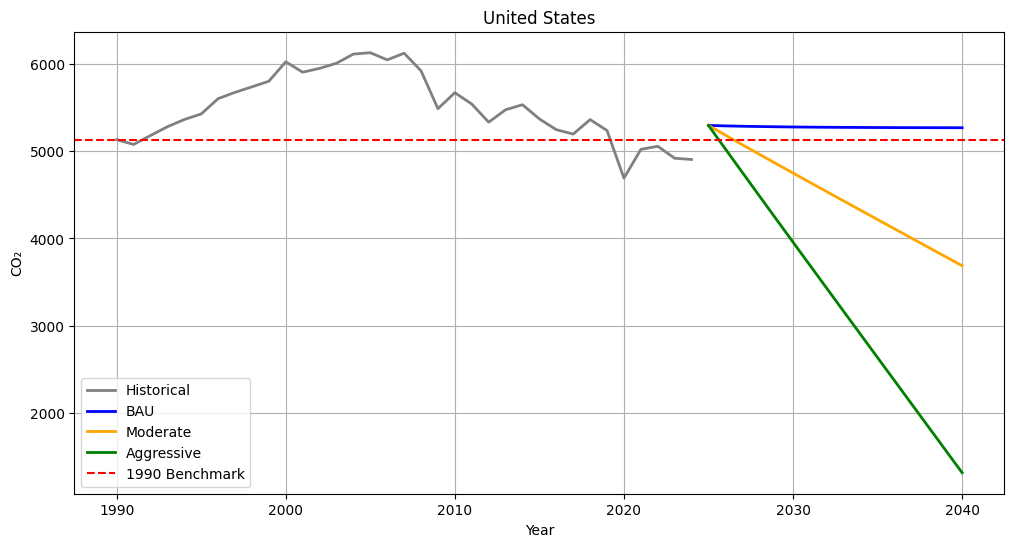

In [100]:
historical=df_features.copy()
colors={
    "BAU":"blue",
    "Moderate":"orange",
    "Aggressive":"green"
}

for country in scenario_df["Country"].unique():
    plt.figure(figsize=(12,6))
    hist=historical[
        historical["country"]==country
    ]
    plt.plot(
        hist["year"],
        hist["co2"],
        color="grey",
        linewidth=2,
        label="Historical"
    )
    for scenario in colors:
        temp=scenario_df[
            (scenario_df["Country"]==country)&
            (scenario_df["Scenario"]==scenario)
        ]

        plt.plot(
            temp["Year"],
            temp["CO2_Projected"],
            color=colors[scenario],
            linewidth=2,
            label=scenario
        )

    benchmark=hist[
        hist["year"]==1990
    ]["co2"].iloc[0]
    plt.axhline(
        benchmark,
        color="red",
        linestyle="--",
        label="1990 Benchmark"
    )
    plt.title(country)
    plt.xlabel("Year")
    plt.ylabel("CO₂")
    plt.legend()
    plt.grid(True)
    plt.show()

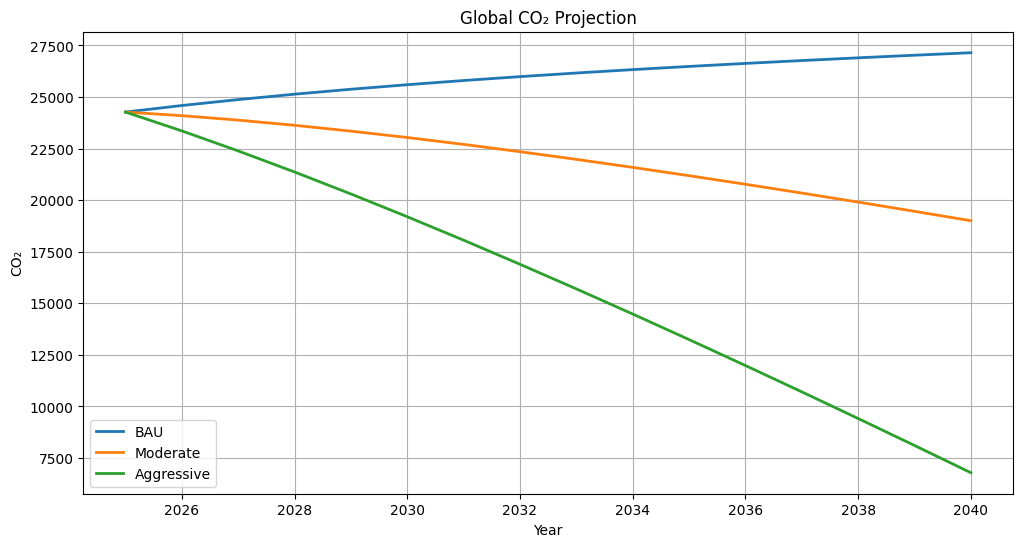

In [101]:
global_projection=(
    scenario_df.groupby(
        ["Year","Scenario"])["CO2_Projected"].sum().reset_index()
)
plt.figure(figsize=(12,6))
for scenario in colors:
    temp=global_projection[
        global_projection["Scenario"]==scenario
    ]
    plt.plot(
        temp["Year"],
        temp["CO2_Projected"],
        linewidth=2,
        label=scenario
    )
plt.title(
    "Global CO₂ Projection"
)
plt.xlabel("Year")
plt.ylabel("CO₂")
plt.grid(True)
plt.legend()
plt.show()

## Impact Summary

To compare the long-term environmental impact of each policy scenario, cumulative CO₂ emissions from 2025 to 2040 are calculated for every country.

In [102]:
impact_summary=(
    scenario_df.groupby(["Country","Scenario"])["CO2_Projected"].sum().reset_index()
)
impact_summary.rename(
    columns={
        "CO2_Projected":"Cumulative_CO2"
    },
    inplace=True
)
impact_summary.head()

,Country,Scenario,Cumulative_CO2
0,Australia,Aggressive,4252.800696
1,Australia,BAU,6831.202592
2,Australia,Moderate,5799.841834
3,Brazil,Aggressive,5088.814184
4,Brazil,BAU,8234.244672


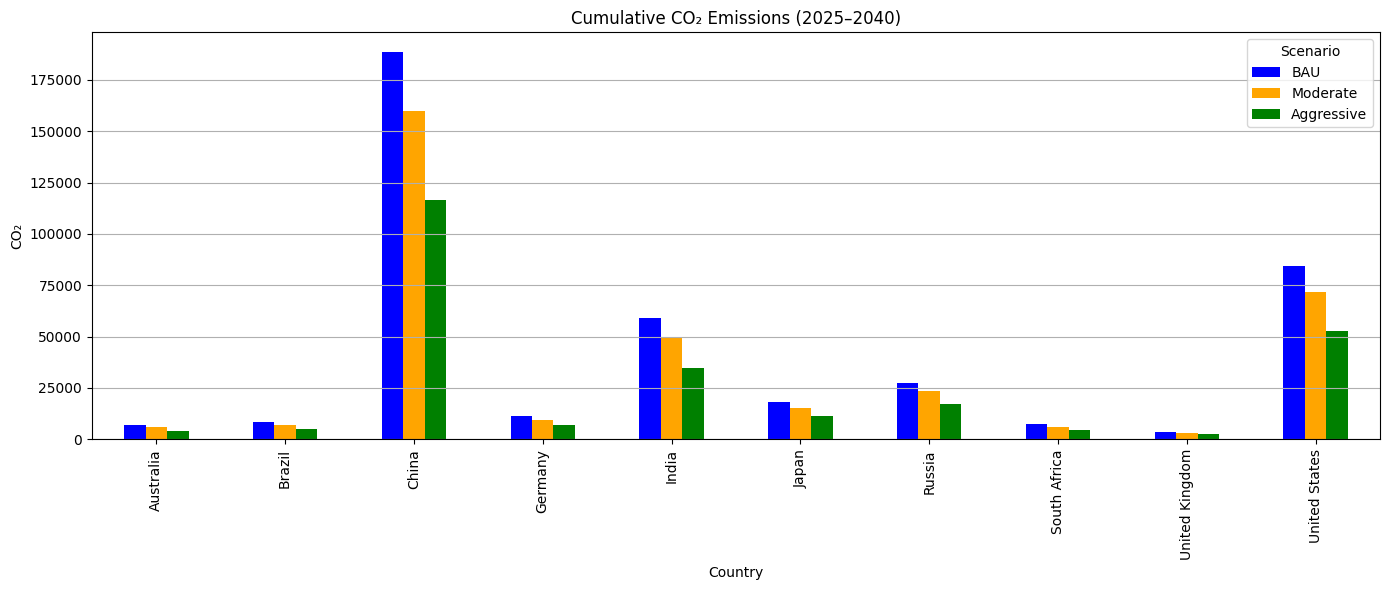

In [103]:
pivot=impact_summary.pivot(
    index="Country",
    columns="Scenario",
    values="Cumulative_CO2"
)
pivot=pivot[
    ["BAU","Moderate","Aggressive"]
]

pivot.plot(
    kind="bar",
    figsize=(14,6),
    color=["blue","orange","green"]
)
plt.title("Cumulative CO₂ Emissions (2025–2040)")
plt.ylabel("CO₂")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [104]:
scenario_projections =  pd.read_csv("data/scenario_projections.csv")
scenario_projections.head()

,Country,Year,Scenario,CO2_Projected
0,Australia,2025,BAU,418.258674
1,Australia,2025,Moderate,418.258674
2,Australia,2025,Aggressive,418.258674
3,Australia,2026,BAU,419.821343
4,Australia,2026,Moderate,411.424916


In [105]:
scenario_impact_summary =  pd.read_csv("data/scenario_impact_summary.csv")
scenario_impact_summary.head()

,Country,Scenario,Cumulative_CO2
0,Australia,Aggressive,4252.800696
1,Australia,BAU,6831.202592
2,Australia,Moderate,5799.841834
3,Brazil,Aggressive,5088.814184
4,Brazil,BAU,8234.244672


## Interpretation

The Business as Usual scenario produces the highest cumulative CO₂ emissions because no mitigation measures are introduced.
The Moderate Mitigation scenario gradually lowers cumulative emissions through a 2% annual reduction beginning in 2025.
The Aggressive Mitigation scenario achieves the largest reduction in emissions across all countries.
Countries with relatively large baseline emissions, including China, India, and the United States, experience the greatest absolute reductions under the Aggressive Mitigation scenario.
These results illustrate the potential long-term benefits of stronger emission reduction policies.

In [106]:
impact_summary.to_csv(
    "data/scenario_impact_summary.csv",
    index=False
)
print("Impact summary saved.")

Impact summary saved.


## Week 5 Summary

In this notebook, scenario analysis was performed using the ETS(A,Ad,N) forecast developed in Week 4.
Three policy scenarios—Business as Usual, Moderate Mitigation, and Aggressive Mitigation—were evaluated for all ten countries between 2025 and 2040.
The scenario projections, country-level comparisons, global trends, and cumulative emission analysis demonstrated how stronger mitigation strategies could substantially reduce long-term CO₂ emissions.
Although these scenarios are illustrative rather than policy-calibrated, they provide a useful framework for comparing possible future climate policy outcomes.

In [107]:
import sys
print(sys.executable)

C:\Program Files\Python312\python.exe


In [108]:
!python -m pip install streamlit

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [109]:
!python -m streamlit --version

Streamlit, version 1.59.2
